In [ ]:
# --- INSTALLATION ---
!pip install yfinance newsapi-python pandas

In [ ]:
!pip install gdeltdoc tqdm python-dateutil

In [ ]:
import yfinance as yf
from newsapi import NewsApiClient
import pandas as pd
from datetime import datetime, timedelta

# --- CONFIGURATION ---
NEWS_API_KEY = 'aa1ea6715d584dd2a4f04a9cb6991cd8'
PERIOD_DAYS = 30

def build_pro_dataset():
    end_date = datetime.now().date()
    start_date = end_date - timedelta(days=PERIOD_DAYS)

    print(f"🚀 Construction du dataset professionnel ({start_date} au {end_date})...")

    # 1. MAPPAGE DES NOMS DE COLONNES
    tickers_map = {
        "NG=F": "Prix_Gaz_Naturel",
        "BZ=F": "Prix_Petrole_Brent",
        "ZW=F": "Prix_Ble_Mondial",
        "USDMAD=X": "Taux_Change_USD_MAD",
        "1211.SR": "Cours_Maaden_Saudi"
    }

    # 2. COLLECTE MARCHÉS
    market_data = yf.download(list(tickers_map.keys()), start=start_date, end=end_date, interval="1d")['Close']
    market_data.index = pd.to_datetime(market_data.index).date
    market_data = market_data.rename(columns=tickers_map) # Renommage ici

    # Calendrier complet
    all_days = pd.date_range(start=start_date, end=end_date, freq='D').date
    df = pd.DataFrame(index=all_days).join(market_data).ffill().bfill()

    # 3. COLLECTE NEWS
    newsapi = NewsApiClient(api_key=NEWS_API_KEY)
    df['Volume_News_Risque'] = 0

    for date_obj in all_days:
        try:
            articles = newsapi.get_everything(
                q='Suez OR "Red Sea" OR "Conflict"',
                from_param=date_obj.strftime('%Y-%m-%d'),
                to=date_obj.strftime('%Y-%m-%d'),
                language='en'
            )
            df.loc[date_obj, 'Volume_News_Risque'] = articles['totalResults']
        except:
            continue

    # 4. CALCUL DES FEATURES (Indicateurs d'incertitude)
    df['Score_Risque_Geopolitique'] = df['Volume_News_Risque'].apply(lambda x: min(x / 1500, 1.0))
    df['Volatilite_Gaz_7j'] = df['Prix_Gaz_Naturel'].pct_change(fill_method=None).rolling(window=3).std()


    df = df.fillna(0)

    print("✅ Dataset prêt avec noms explicites !")
    return df.reset_index().rename(columns={'index': 'Date'})

# Exécution
df_final = build_pro_dataset()
df_final.to_csv("poc_dataset_30days.csv", index=False)

df_final.head(40)

🚀 Construction du dataset professionnel (2026-03-18 au 2026-04-17)...


/tmp/ipykernel_61629/3784435719.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market_data = yf.download(list(tickers_map.keys()), start=start_date, end=end_date, interval="1d")['Close']
[*********************100%***********************]  5 of 5 completed


✅ Dataset prêt avec noms explicites !


,Date,Cours_Maaden_Saudi,Prix_Petrole_Brent,Prix_Gaz_Naturel,Taux_Change_USD_MAD,Prix_Ble_Mondial,Volume_News_Risque,Score_Risque_Geopolitique,Volatilite_Gaz_7j
0,2026-03-18,64.849998,107.379997,3.065,9.360000,604.25,1042,0.694667,0.000000
1,2026-03-19,64.849998,108.650002,3.166,9.370000,608.00,1151,0.767333,0.000000
2,2026-03-20,64.849998,112.190002,3.095,9.355000,595.25,1013,0.675333,0.000000
3,2026-03-21,64.849998,112.190002,3.095,9.355000,595.25,497,0.331333,0.027855
4,2026-03-22,64.849998,112.190002,3.095,9.355000,595.25,458,0.305333,0.012948
5,2026-03-23,64.849998,99.940002,2.891,9.035155,587.75,959,0.639333,0.038055
6,2026-03-24,64.849998,104.489998,2.943,9.357000,590.00,962,0.641333,0.044172
7,2026-03-25,65.000000,102.220001,2.952,9.011975,597.75,973,0.648667,0.044757
8,2026-03-26,64.500000,108.010002,2.999,9.325000,605.00,1100,0.733333,0.008089
9,2026-03-27,64.500000,112.570000,3.095,9.031621,605.00,1071,0.714000,0.014506


In [ ]:
import pandas as pd
df_final=pd.read_csv("poc_dataset_30days.csv")


In [ ]:
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler

# Préparation des données
scaler = MinMaxScaler()
cols_to_plot = ['Prix_Gaz_Naturel', 'Prix_Petrole_Brent', 'Taux_Change_USD_MAD']
df_scaled = df_final.copy()
df_scaled[cols_to_plot] = scaler.fit_transform(df_final[cols_to_plot])

fig1 = go.Figure()
for col in cols_to_plot:
    fig1.add_trace(go.Scatter(x=df_scaled['Date'], y=df_scaled[col], name=col, mode='lines+markers'))

fig1.update_layout(
    title="Analyse Comparative de la Volatilité des Coûts (Indexé 0-1)",
    xaxis_title="Date",
    yaxis_title="Valeur Normalisée",
    template="plotly_dark",
    hovermode="x unified"
)
fig1.show()

In [ ]:
import plotly.express as px

fig2 = px.scatter(df_final,
                 x="Volume_News_Risque",
                 y="Volatilite_Gaz_7j",
                 size="Score_Risque_Geopolitique",
                 color="Prix_Gaz_Naturel",
                 hover_name="Date",
                 title="Impact des Tensions Géopolitiques sur la Volatilité de l'Énergie",
                 labels={"Volume_News_Risque": "Nombre d'Articles (Crises)", "Volatilite_Gaz_7j": "Volatilité Gaz (7j)"},
                 template="plotly_white")

fig2.update_layout(coloraxis_colorbar=dict(title="Prix Gaz"))
fig2.show()

In [ ]:
import plotly.graph_objects as go

latest_risk = df_final['Score_Risque_Geopolitique'].iloc[-2] * 100

fig3 = go.Figure(go.Indicator(
    mode = "gauge+number+delta",
    value = latest_risk,
    domain = {'x': [0, 1], 'y': [0, 1]},
    title = {'text': "Indice d'Incertitude Actuel (Supply Chain)", 'font': {'size': 24}},
    delta = {'reference': df_final['Score_Risque_Geopolitique'].mean() * 100, 'increasing': {'color': "red"}},
    gauge = {
        'axis': {'range': [None, 100], 'tickwidth': 1},
        'bar': {'color': "darkblue"},
        'bgcolor': "white",
        'borderwidth': 2,
        'bordercolor': "gray",
        'steps': [
            {'range': [0, 30], 'color': 'green'},
            {'range': [30, 70], 'color': 'orange'},
            {'range': [70, 100], 'color': 'red'}],
        'threshold': {
            'line': {'color': "black", 'width': 4},
            'thickness': 0.75,
            'value': 90}}))

fig3.update_layout(paper_bgcolor = "lavender", font = {'color': "darkblue", 'family': "Arial"})
fig3.show()

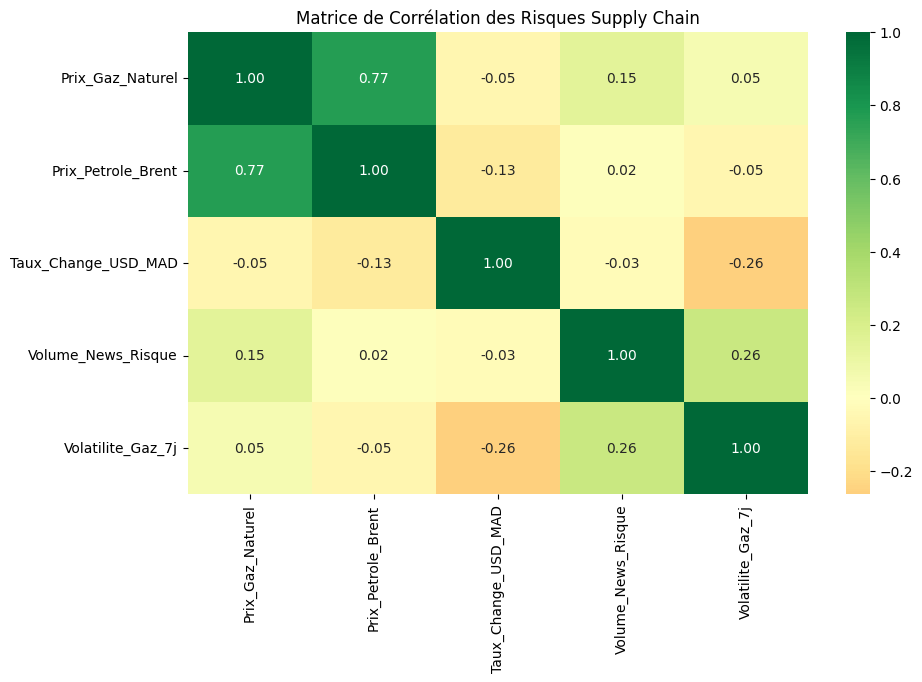

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
correlation_matrix = df_final[['Prix_Gaz_Naturel', 'Prix_Petrole_Brent', 'Taux_Change_USD_MAD', 'Volume_News_Risque', 'Volatilite_Gaz_7j']].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', center=0, fmt=".2f")
plt.title("Matrice de Corrélation des Risques Supply Chain")
plt.show()

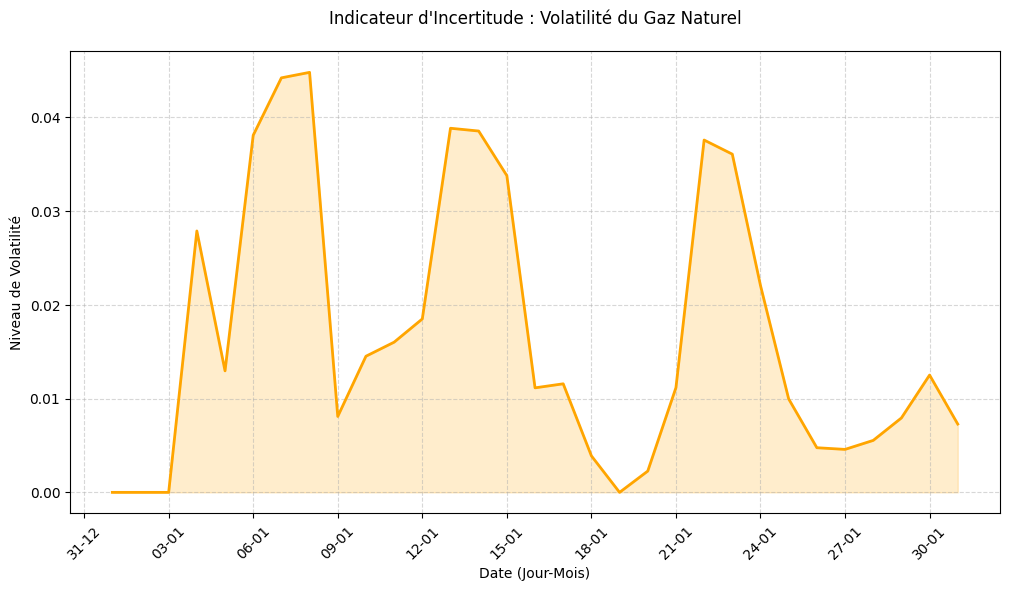

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates # Pour gérer les dates
import os

# 1. Préparation des données
vol = df_final['Volatilite_Gaz_7j']

plt.figure(figsize=(12, 6)) # Un peu plus large pour laisser respirer les dates
plt.plot(df_final['Date'], vol, color='orange', linewidth=2, label='Volatilité (Écart-type 3j)')
plt.fill_between(df_final['Date'], vol, color='orange', alpha=0.2)

# 2. MODIFICATION DE L'AXE X (C'est ici que ça se passe)
ax = plt.gca() # Récupérer l'axe actuel

# On n'affiche qu'une date tous les 3 jours pour éviter l'encombrement
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))

# On définit le format : Jour/Mois
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))

# Rotation des étiquettes
plt.xticks(rotation=45)

# 3. Design et Sauvegarde
plt.title("Indicateur d'Incertitude : Volatilité du Gaz Naturel", pad=20)
plt.xlabel("Date (Jour-Mois)")
plt.ylabel("Niveau de Volatilité")
plt.grid(True, linestyle='--', alpha=0.5)

if not os.path.exists('images'): os.makedirs('images')
plt.savefig("images/volatilite_gaz_clean.png", dpi=300, bbox_inches='tight')
plt.show()

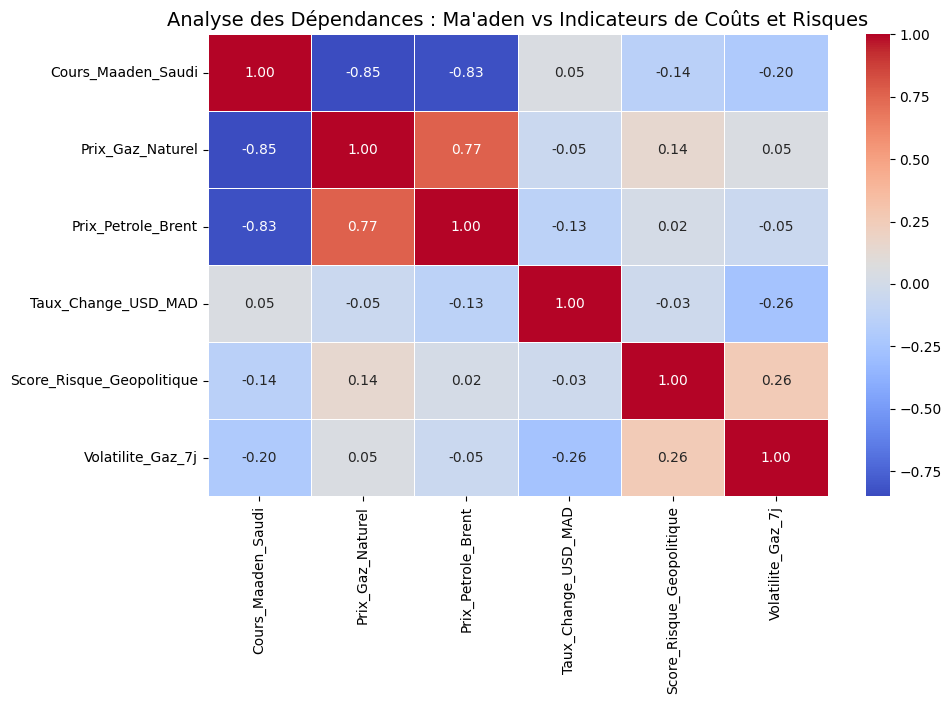

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Préparation des données pour la corrélation
cols_corr = [
    'Cours_Maaden_Saudi', 'Prix_Gaz_Naturel', 'Prix_Petrole_Brent',
    'Taux_Change_USD_MAD', 'Score_Risque_Geopolitique', 'Volatilite_Gaz_7j'
]

plt.figure(figsize=(10, 6))
correlation_matrix = df_final[cols_corr].corr()

# Création du heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Analyse des Dépendances : Ma'aden vs Indicateurs de Coûts et Risques", fontsize=14)
plt.show()

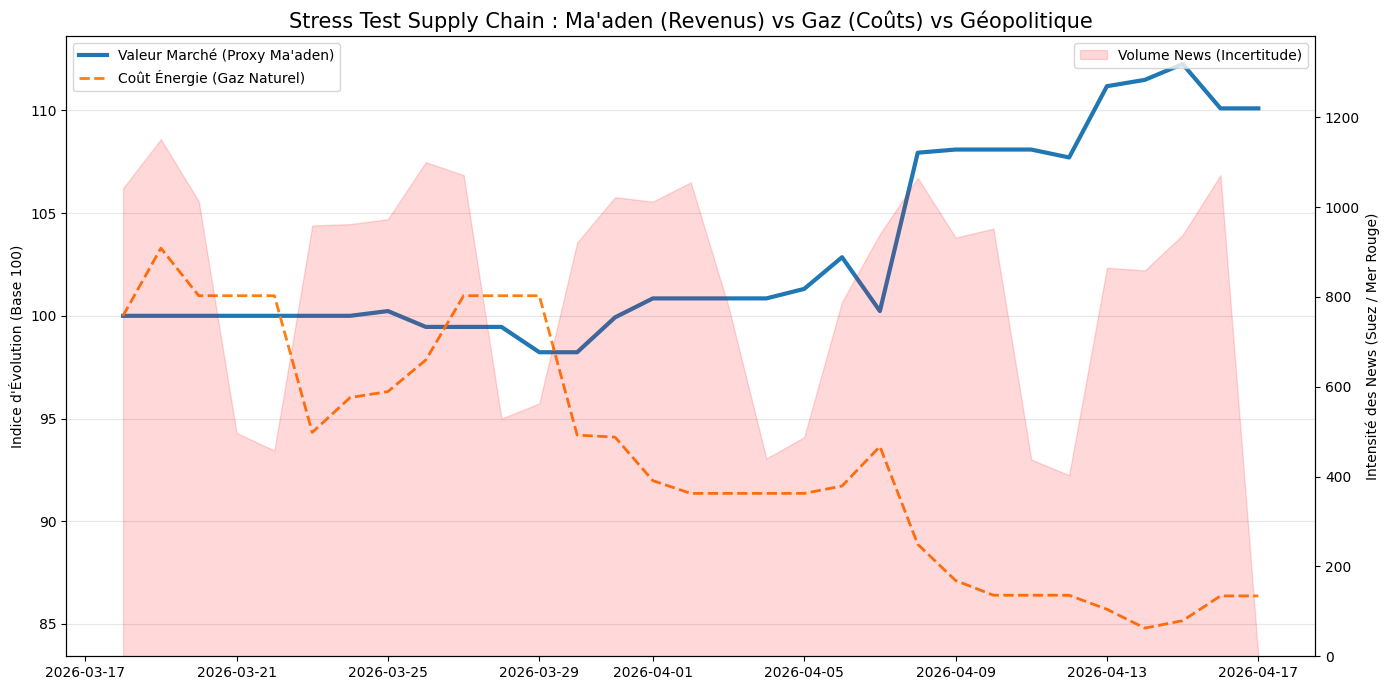

In [ ]:
import matplotlib.pyplot as plt

# Conversion de la date si nécessaire
df_final['Date'] = pd.to_datetime(df_final['Date'])

fig, ax1 = plt.subplots(figsize=(14, 7))

# --- AXE GAUCHE : Indices de Valeur (Base 100 pour comparer des pommes et des oranges) ---
# On divise par la première valeur pour voir l'évolution en pourcentage
base_maaden = df_final['Cours_Maaden_Saudi'] / df_final['Cours_Maaden_Saudi'].iloc[0] * 100
base_gaz = df_final['Prix_Gaz_Naturel'] / df_final['Prix_Gaz_Naturel'].iloc[0] * 100

ax1.plot(df_final['Date'], base_maaden, label="Valeur Marché (Proxy Ma'aden)", color='#1f77b4', linewidth=3)
ax1.plot(df_final['Date'], base_gaz, label="Coût Énergie (Gaz Naturel)", color='#ff7f0e', linestyle='--', linewidth=2)

ax1.set_ylabel("Indice d'Évolution (Base 100)")
ax1.legend(loc='upper left')
ax1.grid(axis='y', alpha=0.3)

# --- AXE DROIT : Volume de News (L'Incertitude brute) ---
ax2 = ax1.twinx()
ax2.fill_between(df_final['Date'], df_final['Volume_News_Risque'], color='red', alpha=0.15, label="Volume News (Incertitude)")
ax2.set_ylabel("Intensité des News (Suez / Mer Rouge)")
ax2.set_ylim(0, df_final['Volume_News_Risque'].max() * 1.2) # Marge haute pour la lisibilité
ax2.legend(loc='upper right')

plt.title("Stress Test Supply Chain : Ma'aden (Revenus) vs Gaz (Coûts) vs Géopolitique", fontsize=15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Yfinance

In [ ]:
import yfinance as yf
import pandas as pd
from datetime import datetime

# 1. Configuration des paramètres d'extraction
START_DATE = "2016-01-01"
END_DATE = "2026-04-20"
FILE_NAME = "raw_yfinance_data_2016_2026.csv"

# Mapping des tickers (Piliers : Énergie, Logistique, Marché, Macro)
tickers_map = {
    "NG=F": "Prix_Gaz_Naturel",
    "BZ=F": "Prix_Petrole_Brent",
    "ZW=F": "Prix_Ble_Mondial",
    "USDMAD=X": "Taux_Change_USD_MAD",
    "1211.SR": "Cours_Maaden_Saudi",
    "BDRY": "Indice_Fret_Maritime",
    "MOS": "Cours_Mosaic_USA"
}

def extract_raw_yfinance():
    print(f"--- Extraction brute yfinance lancée (Période: {START_DATE} à {END_DATE}) ---")

    # Téléchargement des données brutes
    # On récupère toutes les colonnes (Open, High, Low, Close, Volume) au cas où
    raw_data = yf.download(list(tickers_map.keys()), start=START_DATE, end=END_DATE, interval="1d")

    # On garde la structure multi-indexée brute ou on aplatit juste les colonnes
    # Pour faciliter le futur merge, on va juste isoler le 'Close' mais sans nettoyage
    df_close = raw_data['Close'].copy()

    # Renommage direct
    df_close = df_close.rename(columns=tickers_map)

    # Reset de l'index pour avoir la colonne 'Date'
    df_close.reset_index(inplace=True)

    # Sauvegarde du CSV brut
    df_close.to_csv(FILE_NAME, index=False)

    print(f"--- Extraction terminée. Fichier sauvegardé : {FILE_NAME} ---")
    return df_close

# Exécution
df_raw = extract_raw_yfinance()

# Aperçu du contenu brut (avec les potentiels NaN des jours fériés)
print("\nAperçu des données brutes (Extraites telles quelles) :")
print(df_raw.head())

--- Extraction brute yfinance lancée (Période: 2016-01-01 à 2026-04-20) ---


/tmp/ipykernel_1859/1172349043.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(list(tickers_map.keys()), start=START_DATE, end=END_DATE, interval="1d")
[*********************100%***********************]  7 of 7 completed


--- Extraction terminée. Fichier sauvegardé : raw_yfinance_data_2016_2026.csv ---

Aperçu des données brutes (Extraites telles quelles) :
Ticker       Date  Cours_Maaden_Saudi  Indice_Fret_Maritime  \
0      2016-01-01                 NaN                   NaN   
1      2016-01-03           11.276666                   NaN   
2      2016-01-04           11.286666                   NaN   
3      2016-01-05           11.246666                   NaN   
4      2016-01-06           10.470000                   NaN   

Ticker  Prix_Petrole_Brent  Cours_Mosaic_USA  Prix_Gaz_Naturel  \
0                      NaN               NaN               NaN   
1                      NaN               NaN               NaN   
2                37.220001         23.230671             2.334   
3                36.419998         23.132593             2.325   
4                34.230000         21.612217             2.267   

Ticker  Taux_Change_USD_MAD  Prix_Ble_Mondial  
0                    9.5857           

In [ ]:
df_raw[D]

Ticker,Date,Cours_Maaden_Saudi,Indice_Fret_Maritime,Prix_Petrole_Brent,Cours_Mosaic_USA,Prix_Gaz_Naturel,Taux_Change_USD_MAD,Prix_Ble_Mondial
0,2016-01-01,NaN,NaN,NaN,NaN,NaN,9.5857,NaN
1,2016-01-03,11.276666,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-01-04,11.286666,NaN,37.220001,23.230671,2.334,9.9150,458.25
3,2016-01-05,11.246666,NaN,36.419998,23.132593,2.325,9.9739,461.25
4,2016-01-06,10.470000,NaN,34.230000,21.612217,2.267,9.9388,462.75
5,2016-01-07,9.746666,NaN,33.750000,20.868376,2.382,9.8578,468.50
6,2016-01-08,NaN,NaN,33.549999,20.361589,2.472,9.5222,478.50
7,2016-01-10,9.746666,NaN,NaN,NaN,NaN,NaN,NaN
8,2016-01-11,9.746666,NaN,31.549999,19.454268,2.396,9.6462,469.00
9,2016-01-12,9.970000,NaN,30.860001,20.075489,2.257,9.9080,481.25


In [ ]:
# Pourcentage de valeurs nulles
null_percent = df_raw.isnull().mean() * 100

# Pourcentage de valeurs non nulles
notnull_percent = df_raw.notnull().mean() * 100

# Combiner dans un seul tableau
summary = pd.DataFrame({
    'Pourcentage_Null (%)': null_percent,
    'Pourcentage_Non_Null (%)': notnull_percent
})

print(summary)


                      Pourcentage_Null (%)  Pourcentage_Non_Null (%)
Ticker                                                              
Date                              0.000000                100.000000
Cours_Maaden_Saudi               19.075866                 80.924134
Indice_Fret_Maritime             36.653138                 63.346862
Prix_Petrole_Brent               19.200749                 80.799251
Cours_Mosaic_USA                 19.231970                 80.768030
Prix_Gaz_Naturel                 19.200749                 80.799251
Taux_Change_USD_MAD              16.328442                 83.671558
Prix_Ble_Mondial                 19.263191                 80.736809


In [ ]:
import pandas as pd

# Conversion date + extraction année
df_raw['Date'] = pd.to_datetime(df_raw['Date'])
df_raw['Year'] = df_raw['Date'].dt.year

# Calcul des pourcentages null / non-null par année
summary_by_year = pd.concat(
    [
        df_raw.groupby('Year').apply(lambda x: x.isnull().mean() * 100).add_suffix('_Null_%'),
        df_raw.groupby('Year').apply(lambda x: x.notnull().mean() * 100).add_suffix('_NonNull_%')
    ],
    axis=1
)

# Affichage
summary_by_year.head(12)


/tmp/ipykernel_1859/2669743936.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_raw.groupby('Year').apply(lambda x: x.isnull().mean() * 100).add_suffix('_Null_%'),
/tmp/ipykernel_1859/2669743936.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_raw.groupby('Year').apply(lambda x: x.notnull().mean() * 100).add_suffix('_NonNull_%')


Ticker,Date_Null_%,Cours_Maaden_Saudi_Null_%,Indice_Fret_Maritime_Null_%,Prix_Petrole_Brent_Null_%,Cours_Mosaic_USA_Null_%,Prix_Gaz_Naturel_Null_%,Taux_Change_USD_MAD_Null_%,Prix_Ble_Mondial_Null_%,Year_Null_%,Date_NonNull_%,Cours_Maaden_Saudi_NonNull_%,Indice_Fret_Maritime_NonNull_%,Prix_Petrole_Brent_NonNull_%,Cours_Mosaic_USA_NonNull_%,Prix_Gaz_Naturel_NonNull_%,Taux_Change_USD_MAD_NonNull_%,Prix_Ble_Mondial_NonNull_%,Year_NonNull_%
Year,,,,,,,,,,,,,,,,,,
2016,0.0,21.221865,100.000000,19.614148,18.971061,19.614148,16.077170,19.614148,0.0,100.0,78.778135,0.000000,80.385852,81.028939,80.385852,83.922830,80.385852,100.0
2017,0.0,17.628205,100.000000,19.551282,19.551282,19.551282,16.666667,19.551282,0.0,100.0,82.371795,0.000000,80.448718,80.448718,80.448718,83.333333,80.448718,100.0
2018,0.0,16.613419,37.380192,19.808307,19.808307,19.808307,16.613419,19.808307,0.0,100.0,83.386581,62.619808,80.191693,80.191693,80.191693,83.386581,80.191693,100.0
2019,0.0,16.932907,19.488818,19.488818,19.488818,19.488818,16.932907,19.488818,0.0,100.0,83.067093,80.511182,80.511182,80.511182,80.511182,83.067093,80.511182,100.0
2020,0.0,19.551282,18.910256,18.910256,18.910256,18.910256,16.025641,18.910256,0.0,100.0,80.448718,81.089744,81.089744,81.089744,81.089744,83.974359,81.089744,100.0
2021,0.0,19.614148,18.971061,18.971061,18.971061,18.971061,16.077170,18.971061,0.0,100.0,80.385852,81.028939,81.028939,81.028939,81.028939,83.922830,81.028939,100.0
2022,0.0,20.000000,19.032258,19.032258,19.032258,19.032258,16.129032,19.032258,0.0,100.0,80.000000,80.967742,80.967742,80.967742,80.967742,83.870968,80.967742,100.0
2023,0.0,19.677419,19.354839,19.032258,19.354839,19.032258,16.129032,19.354839,0.0,100.0,80.322581,80.645161,80.967742,80.645161,80.967742,83.870968,80.645161,100.0
2024,0.0,19.935691,18.971061,18.971061,18.971061,18.971061,15.755627,18.971061,0.0,100.0,80.064309,81.028939,81.028939,81.028939,81.028939,84.244373,81.028939,100.0


In [ ]:
import pandas as pd

# Convertir la colonne Date en datetime (si ce n'est pas déjà fait)
df_raw['Date'] = pd.to_datetime(df_raw['Date'])

# Filtrer l'année 2016
df_2026 = df_raw[df_raw['Date'].dt.year == 2026]

# Afficher le résultat
df_2026


Ticker,Date,Cours_Maaden_Saudi,Indice_Fret_Maritime,Prix_Petrole_Brent,Cours_Mosaic_USA,Prix_Gaz_Naturel,Taux_Change_USD_MAD,Prix_Ble_Mondial,Year
3112,2026-01-01,60.849998,NaN,NaN,NaN,NaN,NaN,NaN,2026
3113,2026-01-02,NaN,8.46,60.750000,24.810787,3.618,8.835721,506.50,2026
3114,2026-01-04,59.599998,NaN,NaN,NaN,NaN,NaN,NaN,2026
3115,2026-01-05,61.000000,8.72,61.759998,24.662043,3.523,8.862884,512.50,2026
3116,2026-01-06,64.500000,8.81,60.700001,24.949617,3.350,9.015000,510.50,2026
...,...,...,...,...,...,...,...,...,...
3198,2026-04-14,72.300003,11.42,94.790001,23.940001,2.599,9.252500,592.00,2026
3199,2026-04-15,72.800003,11.40,94.930000,23.730000,2.610,9.235000,593.75,2026
3200,2026-04-16,71.400002,11.13,99.389999,24.730000,2.647,9.230000,598.50,2026
3201,2026-04-17,NaN,11.44,90.379997,24.570000,2.674,9.231000,591.25,2026


# Gdelt

In [ ]:
from gdeltdoc import GdeltDoc, Filters
import pandas as pd
import time
import json
from tqdm import tqdm

# Fenêtre de 3 ans pour la stabilité
START_DATE = "2023-01-01"
END_DATE = "2026-04-20"
FILE_CSV = "raw_gdelt_full_rigor_2023_2026.csv"
FILE_JSON = "media_context_links.json"

# Requêtes simplifiées (1 ou 2 mots-clés maximum par thématique)
# L'API GDELT Doc préfère les termes uniques très précis
risk_themes = {
    "Logistics": "Suez Canal",
    "Energy": "Natural Gas",
    "Market": "Phosphate",
    "Agro_Climate": "Drought",
    "Policy_Trade": "Fertilizer subsidy",
    "Macro_Risk": "Inflation"
}

def extract_gdelt_master():
    gd = GdeltDoc()
    all_dfs = []
    image_links = {}

    print(f"Lancement de l'extraction GDELT (Periode: {START_DATE} a {END_DATE})")

    for name, query in tqdm(risk_themes.items(), desc="Extraction des thématiques"):
        # On enlève les guillemets complexes pour cette itération
        f = Filters(keyword=query, start_date=START_DATE, end_date=END_DATE)

        try:
            # On tente uniquement le Volume en premier pour isoler l'erreur
            df_vol = gd.timeline_search("timelinevol", f)
            time.sleep(3)

            df_tone = gd.timeline_search("timelinetone", f)
            time.sleep(3)

            df_clout = gd.timeline_search("timelineclout", f)

            if not df_vol.empty:
                df_vol = df_vol.rename(columns={"datetime": "Date", "volume": f"Vol_{name}"})
                df_tone = df_tone.rename(columns={"datetime": "Date", "average_tone": f"Tone_{name}"})
                df_clout = df_clout.rename(columns={"datetime": "Date", "clout": f"Clout_{name}"})

                for df in [df_vol, df_tone, df_clout]:
                    df['Date'] = pd.to_datetime(df['Date'])

                df_theme = pd.merge(df_vol, df_tone, on="Date", how="outer")
                df_theme = pd.merge(df_theme, df_clout, on="Date", how="outer")
                all_dfs.append(df_theme)

                # Image
                collage_url = gd.image_search(f)
                image_links[name] = str(collage_url)

            time.sleep(4)

        except Exception as e:
            print(f"\nErreur critique sur {name}: {e}")

    if all_dfs:
        df_final = all_dfs[0]
        for next_df in all_dfs[1:]:
            df_final = pd.merge(df_final, next_df, on="Date", how="outer")

        df_final.to_csv(FILE_CSV, index=False)
        with open(FILE_JSON, 'w') as f:
            json.dump(image_links, f, indent=4)

        print(f"\nEXTRACTION TERMINEE - Fichier: {FILE_CSV}")
        return df_final, image_links

    print("\nAucune donnée récupérée. Vérifiez la connexion à l'API.")
    return None, None

df_gdelt_raw, collages = extract_gdelt_master()

Lancement de l'extraction GDELT (Periode: 2023-01-01 a 2026-04-20)


Extraction des thématiques:  17%|█▋        | 1/6 [00:01<00:07,  1.59s/it]


Erreur critique sur Logistics: 


Extraction des thématiques:  33%|███▎      | 2/6 [00:13<00:30,  7.65s/it]


Erreur critique sur Energy: 


...


Erreur critique sur Agro_Climate: Mode timelineclout not in supported API modes


Extraction des thématiques:  83%|████████▎ | 5/6 [00:31<00:06,  6.22s/it]


Erreur critique sur Policy_Trade: 


Extraction des thématiques: 100%|██████████| 6/6 [00:33<00:00,  5.50s/it]


Erreur critique sur Macro_Risk: 

Aucune donnée récupérée. Vérifiez la connexion à l'API.


In [ ]:
import requests
import pandas as pd
import time
import json
from tqdm import tqdm
from datetime import datetime
from dateutil.relativedelta import relativedelta

# --- CONFIGURATION ---
START_DATE = "2016-01-01"
END_DATE   = "2026-04-20"
FILE_CSV   = "raw_gdelt_full_rigor_2016_2026.csv"
FILE_JSON  = "media_context_links.json"

METRICS = {
    "timelinevol":  "Vol",
    "timelinetone": "Tone",
}

risk_themes = {
    "Logistics":    ["Suez Canal", "Red Sea", "Bab el-Mandeb", "Shipping freight"],
    "Energy":       ["Natural Gas", "Ammonia", "Energy crisis", "LNG price"],
    "Market":       ["Fertilizer prices", "Phosphate market", "Potash"],
    "Agro_Climate": ["Drought", "Monsoon", "Crop yield", "Agricultural crisis"],
    "Policy_Trade": ["Export ban", "Fertilizer subsidy", "Trade tariffs"],
    "Macro_Risk":   ["Dollar strength", "Inflation", "Geopolitical sanctions"],
}

GDELT_API = "https://api.gdeltproject.org/api/v2/doc/doc"

def generate_quarters(start: str, end: str):
    periods = []
    cur = datetime.strptime(start, "%Y-%m-%d")
    end_dt = datetime.strptime(end, "%Y-%m-%d")
    while cur < end_dt:
        nxt = min(cur + relativedelta(months=3), end_dt)
        periods.append((cur.strftime("%Y%m%d%H%M%S"), nxt.strftime("%Y%m%d%H%M%S")))
        cur = nxt
    return periods

def parse_date_safe(date_str: str):
    """
    ✅ FIX : gère tous les formats retournés par GDELT :
    - '20180101T000000Z'  (avec Z)
    - '20180101T000000'   (sans Z)
    """
    return date_str.rstrip("Z")  # strip le Z s'il existe, sinon no-op

def fetch_gdelt_raw(keyword: str, mode: str, startdt: str, enddt: str, retries=3):
    params = {
        "query":          keyword,
        "mode":           mode,
        "startdatetime":  startdt,
        "enddatetime":    enddt,
        "timelinesmooth": 3,
        "format":         "json",
        "maxrecords":     250,
    }
    for attempt in range(retries):
        try:
            r = requests.get(GDELT_API, params=params, timeout=30)

            # Réponse vide ou erreur HTTP → pas de données, pas d'erreur à afficher
            if r.status_code != 200 or not r.text.strip():
                return None

            data = r.json()
            timeline = data.get("timeline", [])
            if not timeline:
                return None

            rows = timeline[0].get("data", [])
            if not rows:
                return None

            df = pd.DataFrame(rows)

            # ✅ FIX PRINCIPAL : strip "Z" avant parsing
            df["Date"] = pd.to_datetime(
                df["date"].str.rstrip("Z"),
                format="%Y%m%dT%H%M%S"
            )
            df = df.rename(columns={"value": "val"})[["Date", "val"]]
            return df

        except requests.exceptions.Timeout:
            time.sleep(2 * (attempt + 1))
        except ValueError as e:
            # Erreur de parsing date — on log pour debug
            print(f"    ⚠ date parse | '{keyword}' [{startdt[:8]}]: {e}")
            return None
        except Exception as e:
            # Réponse vide JSON → silence (cas "Expecting value")
            if "Expecting value" not in str(e):
                print(f"    ⚠ {mode} | '{keyword}' [{startdt[:8]}]: {e}")
            return None
    return None

def extract_gdelt_master():
    quarters = generate_quarters(START_DATE, END_DATE)
    print(f"Périodes : {len(quarters)} fenêtres de 3 mois\n")

    all_theme_dfs = []
    image_links   = {}

    for theme_name, keywords in tqdm(risk_themes.items(), desc="Thématiques"):
        theme_metric_dfs = {m: [] for m in METRICS}

        for kw in tqdm(keywords, desc=f"  {theme_name}", leave=False):
            for (q_start, q_end) in quarters:
                for mode in METRICS:
                    df = fetch_gdelt_raw(kw, mode, q_start, q_end)
                    if df is not None and not df.empty:
                        theme_metric_dfs[mode].append(df)
                    time.sleep(0.8)

        # Agréger par métrique puis merger
        merged = None
        for mode, col_prefix in METRICS.items():
            parts = theme_metric_dfs[mode]
            if not parts:
                continue
            df_all = pd.concat(parts, ignore_index=True)
            df_agg = (
                df_all.groupby("Date")["val"]
                .mean()
                .reset_index()
                .rename(columns={"val": f"{col_prefix}_{theme_name}"})
            )
            merged = df_agg if merged is None else pd.merge(
                merged, df_agg, on="Date", how="outer"
            )

        if merged is not None:
            all_theme_dfs.append(merged)
            # Sauvegarde intermédiaire après chaque thématique ✅
            merged.to_csv(f"gdelt_partial_{theme_name}.csv", index=False)
            print(f"\n  💾 Sauvegardé : gdelt_partial_{theme_name}.csv ({len(merged)} lignes)")

        image_links[theme_name] = (
            f"https://api.gdeltproject.org/api/v2/doc/doc"
            f"?query={keywords[0]}&mode=imagecollage&format=html"
        )
        time.sleep(2)

    # Merge final
    if all_theme_dfs:
        df_final = all_theme_dfs[0]
        for nxt in all_theme_dfs[1:]:
            df_final = pd.merge(df_final, nxt, on="Date", how="outer")

        df_final = df_final.sort_values("Date").reset_index(drop=True)
        df_final.to_csv(FILE_CSV, index=False)

        with open(FILE_JSON, "w") as f:
            json.dump(image_links, f, indent=4)

        print(f"\n✅ TERMINÉ — {len(df_final)} lignes × {len(df_final.columns)} colonnes")
        print(f"   CSV  : {FILE_CSV}")
        print(f"   JSON : {FILE_JSON}")
        return df_final, image_links

    print("⚠ Aucune donnée extraite.")
    return None, None

df_gdelt_raw, collages = extract_gdelt_master()

Périodes : 42 fenêtres de 3 mois



  Logistics:   0%|          | 0/4 [00:00<?, ?it/s]

    ⚠ date parse | 'Suez Canal' [20160101]: Expecting value: line 1 column 1 (char 0)
    ⚠ date parse | 'Suez Canal' [20160101]: Expecting value: line 1 column 1 (char 0)
    ⚠ date parse | 'Suez Canal' [20160701]: Expecting value: line 1 column 1 (char 0)
    ⚠ date parse | 'Suez Canal' [20161001]: Expecting value: line 1 column 1 (char 0)



  Logistics:  25%|██▌       | 1/4 [05:13<15:39, 313.24s/it]

    ⚠ date parse | 'Red Sea' [20160701]: Expecting value: line 1 column 1 (char 0)


...

    ⚠ date parse | 'Geopolitical sanctions' [20160101]: Expecting value: line 1 column 1 (char 0)
    ⚠ date parse | 'Geopolitical sanctions' [20160101]: Expecting value: line 1 column 1 (char 0)
    ⚠ date parse | 'Geopolitical sanctions' [20160401]: Expecting value: line 1 column 1 (char 0)
    ⚠ date parse | 'Geopolitical sanctions' [20160401]: Expecting value: line 1 column 1 (char 0)
    ⚠ date parse | 'Geopolitical sanctions' [20161001]: Expecting value: line 1 column 1 (char 0)



  Macro_Risk: 100%|██████████| 3/3 [14:00<00:00, 301.32s/it]
                                                            


  💾 Sauvegardé : gdelt_partial_Macro_Risk.csv (2978 lignes)


Thématiques: 100%|██████████| 6/6 [1:42:08<00:00, 1021.37s/it]


✅ TERMINÉ — 3336 lignes × 13 colonnes
   CSV  : raw_gdelt_full_rigor_2016_2026.csv
   JSON : media_context_links.json


# Etape A: AMONT

In [ ]:
import yfinance as yf
import pandas as pd
from datetime import datetime

# Configuration des dates pour capter l'historique des crises mondiales
START_DATE = "2008-01-01"
END_DATE = datetime.now().strftime('%Y-%m-%d')

# Dictionnaire de correspondance avec nomenclature explicite (Prix, Indice, Taux)
asset_mapping = {
    "CL=F": "Prix_Energie_Diesel_Brent",
    "NG=F": "Prix_Energie_Gaz_Naturel",
    "XME": "Indice_Inflation_Materiel_Minier",
    "DJT": "Indice_Logistique_Transport_Ferroviaire",
    "HG=F": "Prix_Maintenance_Cuivre",
    "MAD=X": "Taux_Change_USD_MAD"
}

tickers = list(asset_mapping.keys())

In [ ]:
import yfinance as yf
import pandas as pd

def extract_and_rename_clean(symbols_map, start, end):
    """
    Extrait les données journalières de yfinance, gère le renommage
    et comble les jours de fermeture des marchés.
    """
    symbols = list(symbols_map.keys())
    print(f"--- Début de l'extraction ---")
    print(f"Symboles cibles : {symbols}")

    # 1. Téléchargement des données
    # interval='1d' : Données journalières
    # auto_adjust=True : Gère automatiquement les dividendes et les splits
    raw_data = yf.download(
        symbols,
        start=start,
        end=end,
        interval="1d",
        auto_adjust=True
    )

    # 2. Gestion de l'erreur 'Adj Close' / MultiIndex
    # yf.download avec plusieurs symboles crée un MultiIndex (Price, Ticker)
    if 'Close' in raw_data.columns.levels[0]:
        df = raw_data['Close'].copy()
    else:
        # Cas particulier pour un symbole unique ou structure différente
        df = raw_data.copy()

    # 3. Renommage des colonnes selon la nomenclature souhaitée
    df = df.rename(columns=symbols_map)

    # 4. Nettoyage et gestion du calendrier boursier
    # L'interpolation linéaire comble les trous (ex: jours fériés différents selon les pays)
    # bfill et ffill gèrent les manques aux extrémités (début/fin de série)
    #df = df.interpolate(method='linear').bfill().ffill()

    # 5. Sauvegarde du fichier CSV
    output_filename = "Raw_Data_Amont_OCP.csv"
    df.to_csv(output_filename)

    print(f"Extraction terminée avec succès.")
    print(f"Fichier sauvegardé : {output_filename}")
    return df

# --- EXÉCUTION ---
try:
    df_raw = extract_and_rename_clean(asset_mapping, START_DATE, END_DATE)

    # Vérification finale
    print("\n--- Liste des variables extraites ---")
    for col in df_raw.columns:
        print(f"Variable : {col}")

    print("\n--- Aperçu des données (5 dernières lignes) ---")
    print(df_raw.tail())

except Exception as e:
    print(f"Une erreur est survenue : {e}")

[****************      33%                       ]  2 of 6 completed

--- Début de l'extraction ---
Symboles cibles : ['CL=F', 'NG=F', 'XME', 'DJT', 'HG=F', 'MAD=X']


[*********************100%***********************]  6 of 6 completed


Extraction terminée avec succès.
Fichier sauvegardé : Raw_Data_Amont_OCP.csv

--- Liste des variables extraites ---
Variable : Prix_Energie_Diesel_Brent
Variable : Indice_Logistique_Transport_Ferroviaire
Variable : Prix_Maintenance_Cuivre
Variable : Taux_Change_USD_MAD
Variable : Prix_Energie_Gaz_Naturel
Variable : Indice_Inflation_Materiel_Minier

--- Aperçu des données (5 dernières lignes) ---
Ticker      Prix_Energie_Diesel_Brent  \
Date                                    
2026-04-22                  92.959999   
2026-04-23                  95.849998   
2026-04-24                  94.400002   
2026-04-27                  96.370003   
2026-04-28                  99.930000   

Ticker      Indice_Logistique_Transport_Ferroviaire  Prix_Maintenance_Cuivre  \
Date                                                                           
2026-04-22                                     9.48                   6.1200   
2026-04-23                                     9.17                   6.0

In [ ]:
df_raw.shape

(4775, 6)

In [ ]:
# Pourcentage de valeurs nulles
null_percent = df_raw.isnull().mean() * 100

# Pourcentage de valeurs non nulles
notnull_percent = df_raw.notnull().mean() * 100

# Combiner dans un seul tableau
summary = pd.DataFrame({
    'Pourcentage_Null (%)': null_percent,
    'Pourcentage_Non_Null (%)': notnull_percent
})

print(summary)


                                         Pourcentage_Null (%)  \
Ticker                                                          
Prix_Energie_Diesel_Brent                            3.476440   
Indice_Logistique_Transport_Ferroviaire             75.958115   
Prix_Maintenance_Cuivre                              3.476440   
Taux_Change_USD_MAD                                  0.041885   
Prix_Energie_Gaz_Naturel                             3.455497   
Indice_Inflation_Materiel_Minier                     3.476440   

                                         Pourcentage_Non_Null (%)  
Ticker                                                             
Prix_Energie_Diesel_Brent                               96.523560  
Indice_Logistique_Transport_Ferroviaire                 24.041885  
Prix_Maintenance_Cuivre                                 96.523560  
Taux_Change_USD_MAD                                     99.958115  
Prix_Energie_Gaz_Naturel                                96.544503  
Ind

In [ ]:
import pandas as pd

# 1. Préparation des données (on sort la Date de l'index)
df_analysis = df_raw.reset_index()
df_analysis['Year'] = df_analysis.index.year if isinstance(df_analysis.index, pd.DatetimeIndex) else pd.to_datetime(df_analysis.iloc[:,0]).dt.year

# On identifie les colonnes d'actifs (on exclut la date et l'année)
assets_cols = [col for col in df_raw.columns if col not in ['Year']]

# 2. Calcul des statistiques
# Pourcentage de données présentes
non_null_summary = df_raw.groupby(df_raw.index.year).apply(lambda x: x.notnull().mean() * 100).add_suffix('_NonNull_%')

# Pourcentage de données manquantes
null_summary = df_raw.groupby(df_raw.index.year).apply(lambda x: x.isnull().mean() * 100).add_suffix('_Null_%')

# 3. Fusion et ORDONNANCEMENT
# On place d'abord TOUTES les colonnes Non-Null, puis TOUTES les colonnes Null
summary_by_year = pd.concat([non_null_summary, null_summary], axis=1)

# Optionnel : Si vous voulez un affichage encore plus propre,
# on peut trier les colonnes pour que les noms soient groupés
all_non_null_cols = [c for c in summary_by_year.columns if '_NonNull_%' in c]
all_null_cols = [c for c in summary_by_year.columns if '_Null_%' in c]

summary_by_year = summary_by_year[all_non_null_cols + all_null_cols]

# 4. Affichage
summary_by_year.head(22)

Ticker,Prix_Energie_Diesel_Brent_NonNull_%,Indice_Logistique_Transport_Ferroviaire_NonNull_%,Prix_Maintenance_Cuivre_NonNull_%,Taux_Change_USD_MAD_NonNull_%,Prix_Energie_Gaz_Naturel_NonNull_%,Indice_Inflation_Materiel_Minier_NonNull_%,Prix_Energie_Diesel_Brent_Null_%,Indice_Logistique_Transport_Ferroviaire_Null_%,Prix_Maintenance_Cuivre_Null_%,Taux_Change_USD_MAD_Null_%,Prix_Energie_Gaz_Naturel_Null_%,Indice_Inflation_Materiel_Minier_Null_%
Date,,,,,,,,,,,,
2008,96.564885,0.000000,96.564885,100.000000,96.564885,96.564885,3.435115,100.000000,3.435115,0.000000,3.435115,3.435115
2009,96.923077,0.000000,96.923077,100.000000,96.923077,96.923077,3.076923,100.000000,3.076923,0.000000,3.076923,3.076923
2010,96.923077,0.000000,96.923077,100.000000,96.923077,96.923077,3.076923,100.000000,3.076923,0.000000,3.076923,3.076923
2011,96.923077,0.000000,96.923077,100.000000,96.923077,96.923077,3.076923,100.000000,3.076923,0.000000,3.076923,3.076923
2012,95.785441,0.000000,95.785441,100.000000,95.785441,95.785441,4.214559,100.000000,4.214559,0.000000,4.214559,4.214559
2013,96.551724,0.000000,96.551724,100.000000,96.551724,96.551724,3.448276,100.000000,3.448276,0.000000,3.448276,3.448276
2014,96.551724,0.000000,96.551724,100.000000,96.551724,96.551724,3.448276,100.000000,3.448276,0.000000,3.448276,3.448276
2015,96.551724,0.000000,96.551724,100.000000,96.551724,96.551724,3.448276,100.000000,3.448276,0.000000,3.448276,3.448276
2016,95.785441,0.000000,95.785441,100.000000,95.785441,96.551724,4.214559,100.000000,4.214559,0.000000,4.214559,3.448276


In [ ]:
# 1. Téléchargement uniquement du bon ticker pour corriger la colonne
print("Récupération des données historiques pour ^DJT...")
correct_djt = yf.download("^DJT", start=START_DATE, end=END_DATE, interval="1d", auto_adjust=True)

# 2. Remplacement des valeurs dans df_raw
# On utilise map ou update pour injecter les bonnes valeurs de 'Close'
df_raw['Indice_Logistique_Transport_Ferroviaire'] = correct_djt['Close']

# 3. Vérification du résultat pour cette colonne
check_col = df_raw[['Indice_Logistique_Transport_Ferroviaire']].groupby(df_raw.index.year).apply(lambda x: x.notnull().mean() * 100)
print("\n--- État de la colonne Logistique après correction ---")
print(check_col)

[*********************100%***********************]  1 of 1 completed

Récupération des données historiques pour ^DJT...



--- État de la colonne Logistique après correction ---
Ticker  Indice_Logistique_Transport_Ferroviaire
Date                                           
2008                                  96.564885
2009                                  96.923077
2010                                  96.923077
2011                                  96.923077
2012                                  95.785441
2013                                  96.551724
2014                                  96.551724
2015                                  96.551724
2016                                  96.551724
2017                                  96.538462
2018                                  96.168582
2019                                  96.551724
2020                                  96.564885
2021                                  96.551724
2022                                  96.538462
2023                                  96.153846
2024                                  96.183206
2025                            

In [ ]:
# Application de la méthode sur l'ensemble du DataFrame pour boucher les trous (week-ends/fériés)
df_raw = df_raw.interpolate(method='linear').bfill().ffill()

# Vérification finale de toutes les colonnes (ordonnées par Non-Null)
summary_final = df_raw.groupby(df_raw.index.year).apply(lambda x: x.notnull().mean() * 100)
print("\n--- Vérification finale : Complétude de toutes les variables ---")
print(summary_final)


--- Vérification finale : Complétude de toutes les variables ---
Ticker  Prix_Energie_Diesel_Brent  Indice_Logistique_Transport_Ferroviaire  \
Date                                                                         
2008                        100.0                                    100.0   
2009                        100.0                                    100.0   
2010                        100.0                                    100.0   
2011                        100.0                                    100.0   
2012                        100.0                                    100.0   
2013                        100.0                                    100.0   
2014                        100.0                                    100.0   
2015                        100.0                                    100.0   
2016                        100.0                                    100.0   
2017                        100.0                                    100.0  

In [ ]:
# 1. Sauvegarde du DataFrame nettoyé en format CSV
output_csv = "Clean_Data_Amont_OCP.csv"
df_raw.to_csv(output_csv)

# 2. Affichage d'un message de confirmation avec les détails
print(f"Sauvegarde réussie : {output_csv}")
print(f"Dimensions finales : {df_raw.shape}")
print(f"Période : du {df_raw.index.min().date()} au {df_raw.index.max().date()}")

# 3. Affichage du résumé de complétude pour validation visuelle
print("\n--- RÉSUMÉ DE COMPLÉTUDE (DOIT ÊTRE 100% PARTOUT) ---")
summary_final = df_raw.groupby(df_raw.index.year).apply(lambda x: x.notnull().mean() * 100)
print(summary_final)

Sauvegarde réussie : Clean_Data_Amont_OCP.csv
Dimensions finales : (4775, 6)
Période : du 2008-01-01 au 2026-04-28

--- RÉSUMÉ DE COMPLÉTUDE (DOIT ÊTRE 100% PARTOUT) ---
Ticker  Prix_Energie_Diesel_Brent  Indice_Logistique_Transport_Ferroviaire  \
Date                                                                         
2008                        100.0                                    100.0   
2009                        100.0                                    100.0   
2010                        100.0                                    100.0   
2011                        100.0                                    100.0   
2012                        100.0                                    100.0   
2013                        100.0                                    100.0   
2014                        100.0                                    100.0   
2015                        100.0                                    100.0   
2016                        100.0                 

# Analyse de l'Influence des Variables sur les Budgets d'Incertitude ($\beta$)

Ce document établit la liaison entre les indicateurs de marché extraits et les risques opérationnels liés aux activités minières et logistiques de l'OCP.

---

### 📋 Correspondance des Flux de Données (Asset Mapping)

| Symbole yfinance | Nom Variable Projet | Signification dans le Contexte OCP |
| :--- | :--- | :--- |
| **CL=F** | `Prix_Energie_Diesel_Brent` | Coût du carburant pour les dumpers (Mines) et les locomotives thermiques. |
| **NG=F** | `Prix_Energie_Gaz_Naturel` | Indicateur du coût de l'électricité industrielle pour le pompage du Pipeline. |
| **XME** | `Indice_Inflation_Materiel_Minier` | Reflète l'évolution du coût des excavatrices, pièces de rechange et CAPEX. |
| **^DJT** | `Indice_Logistique_Transport_Ferroviaire` | Indice de référence pour les tarifs de fret et la capacité logistique mondiale. |
| **HG=F** | `Prix_Maintenance_Cuivre` | Proxy pour les coûts de maintenance des réseaux électriques et moteurs du Pipeline. |
| **MAD=X** | `Taux_Change_USD_MAD` | Impact de la conversion monétaire sur l'achat d'équipements importés. |

---

## 1. $\beta_{ext}$ : Budget d'Incertitude sur l'Extraction
Ce budget capte l'aléa lié au coût de sortie de la roche phosphatée des mines (**Khouribga, Benguérir, Youssoufia**).

* **Prix_Energie_Diesel_Brent** :
    * *Influence* : Directe et Majeure.
    * *Explication* : L'extraction est une activité de terrassement massive. Le diesel alimente les moteurs des excavatrices, des foreuses et des camions hors-route (dumpers). Une volatilité du Brent crée une incertitude immédiate sur le coût opératoire par tonne extraite.
* **Indice_Inflation_Materiel_Minier** :
    * *Influence* : Structurelle.
    * *Explication* : Cet indice reflète le coût mondial des machines et de la main-d'œuvre spécialisée. S'il augmente, le coût du renouvellement des équipements devient imprévisible.
* **Taux_Change_USD_MAD** :
    * *Influence* : Monétaire.
    * *Explication* : L'OCP achète ses équipements lourds en Dollars. Une dévaluation du Dirham renchérit instantanément le coût des pièces de rechange et des nouvelles acquisitions.

---

## 2. $\beta_{trans, pipe}$ : Budget d'Incertitude sur le Pipeline
Ce budget concerne exclusivement l'axe de transport par pulpe (**Slurry Pipeline**) entre Khouribga et Jorf Lasfar.

* **Prix_Energie_Gaz_Naturel** :
    * *Influence* : Énergétique (Électricité).
    * *Explication* : Le pipeline fonctionne via des stations de pompage électriques massives. Le prix du gaz naturel étant un driver majeur du prix de l'électricité, sa volatilité impacte directement le coût de pompage.
* **Prix_Maintenance_Cuivre** :
    * *Influence* : Infrastructurelle.
    * *Explication* : Le cuivre est un composant critique des moteurs électriques et des réseaux haute tension du pipeline. Son prix sert de "proxy" pour l'incertitude liée aux coûts de maintenance.

---

## 3. $\beta_{trans, train}$ : Budget d'Incertitude sur le Transport Ferroviaire
Ce budget est lié au transport de la roche par l'**ONCF** vers les usines de Safi.

* **Indice_Logistique_Transport_Ferroviaire** :
    * *Influence* : Sectorielle.
    * *Explication* : Cet indice (basé sur le Dow Jones Transportation) reflète la santé et les tarifs du fret. Il capte l'incertitude sur la disponibilité et le coût des capacités de transport ferroviaire.
* **Prix_Energie_Diesel_Brent** :
    * *Influence* : Opérationnelle.
    * *Explication* : Le coût du service ferroviaire reste fortement indexé sur les prix de l'énergie (locomotives thermiques et coût de l'électricité).

---

## 📊 Tableau Récapitulatif pour le Modèle IA

| Variable yfinance | $\beta_{ext}$ (Extraction) | $\beta_{trans,pipe}$ (Pipe) | $\beta_{trans,train}$ (Train) |
| :--- | :---: | :---: | :---: |
| **Prix_Energie_Diesel_Brent** | **Principal** | - | Secondaire |
| **Prix_Energie_Gaz_Naturel** | - | **Principal** | - |
| **Indice_Inflation_Materiel_Minier** | **Principal** | - | - |
| **Indice_Logistique_Transport_Ferroviaire** | - | - | **Principal** |
| **Prix_Maintenance_Cuivre** | - | Secondaire | - |
| **Taux_Change_USD_MAD** | Secondaire | - | Secondaire |

In [ ]:
df_raw.head(60)

Ticker,Prix_Energie_Diesel_Brent,Indice_Logistique_Transport_Ferroviaire,Prix_Maintenance_Cuivre,Taux_Change_USD_MAD,Prix_Energie_Gaz_Naturel,Indice_Inflation_Materiel_Minier
Date,,,,,,
2008-01-01,99.620003,4470.660156,3.05050,7.6515,7.8500,54.679863
2008-01-02,99.620003,4470.660156,3.05050,7.6510,7.8500,54.679863
2008-01-03,99.180000,4418.560059,3.17300,7.6596,7.6740,54.199051
2008-01-04,97.910004,4260.390137,3.14150,7.5782,7.8410,51.881634
2008-01-07,95.089996,4283.180176,3.12500,7.6294,7.8790,50.415508
2008-01-08,96.330002,4146.459961,3.27350,7.6069,7.9670,49.658798
2008-01-09,95.669998,4162.700195,3.26450,7.6176,8.0990,49.288322
2008-01-10,93.709999,4273.990234,3.26100,7.6095,8.2590,50.581032
2008-01-11,92.690002,4187.600098,3.28350,7.5527,8.2100,50.336685


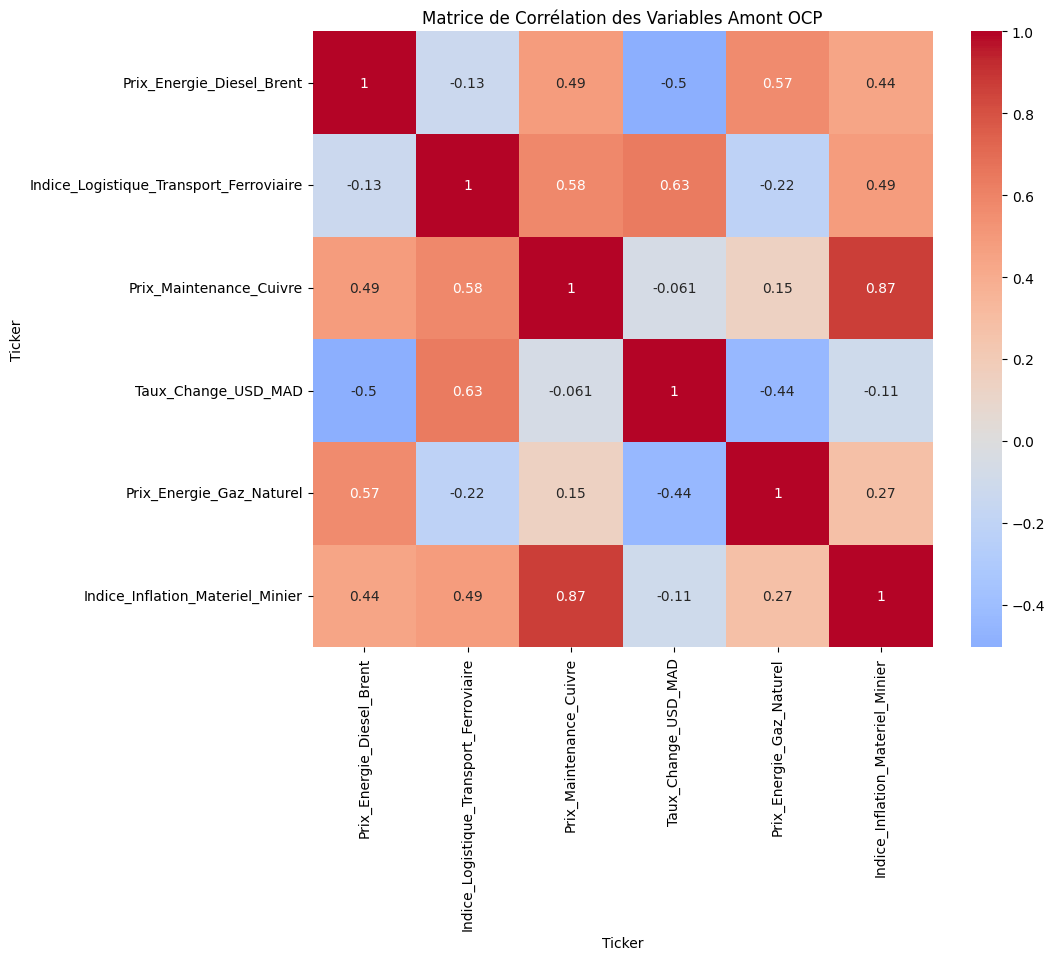

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
correlation_matrix = df_raw.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Matrice de Corrélation des Variables Amont OCP")
plt.show()

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


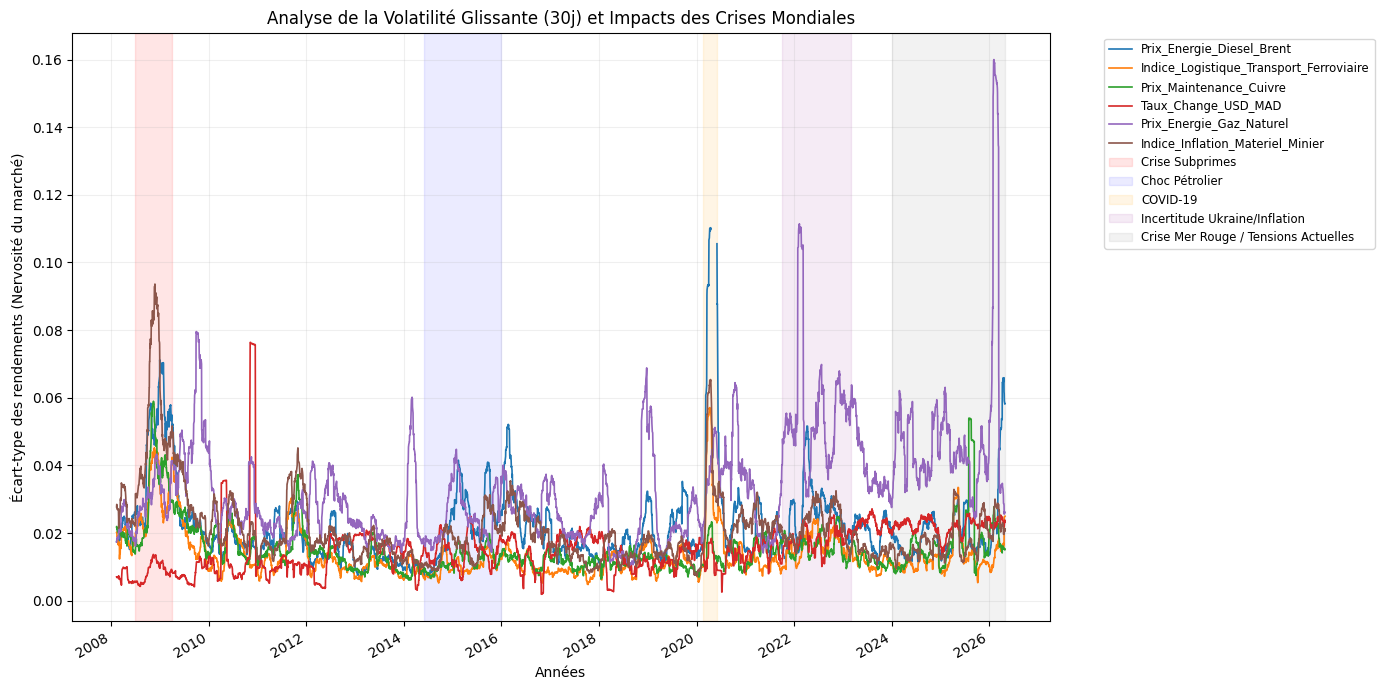

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Calcul des rendements logarithmiques
df_returns = np.log(df_raw / df_raw.shift(1))

# 2. Calcul de la volatilité glissante (30 jours)
# On multiplie par sqrt(252) si on veut une volatilité annualisée,
# mais ici on reste en journalier pour observer les chocs bruts.
volatility_30d = df_returns.rolling(window=30).std()

plt.figure(figsize=(14, 7))
ax = plt.gca()

# Tracé de la volatilité pour chaque variable
volatility_30d.plot(ax=ax, linewidth=1.2)

# --- AJOUT DES ZONES D'OMBRE (CRISES) ---
# On utilise les mêmes périodes que pour le graphique des prix
ax.axvspan('2008-07-01', '2009-04-01', color='red', alpha=0.1, label='Crise Subprimes')
ax.axvspan('2014-06-01', '2016-01-01', color='blue', alpha=0.08, label='Choc Pétrolier')
ax.axvspan('2020-02-15', '2020-06-01', color='orange', alpha=0.1, label='COVID-19')
ax.axvspan('2021-10-01', '2023-03-01', color='purple', alpha=0.08, label='Incertitude Ukraine/Inflation')
ax.axvspan('2024-01-01', '2026-04-30', color='grey', alpha=0.1, label='Crise Mer Rouge / Tensions Actuelles')

# --- CONFIGURATION ---
plt.title("Analyse de la Volatilité Glissante (30j) et Impacts des Crises Mondiales")
plt.ylabel("Écart-type des rendements (Nervosité du marché)")
plt.xlabel("Années")

# On déplace la légende pour ne pas masquer les pics
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True, alpha=0.2)
plt.tight_layout()

plt.show()

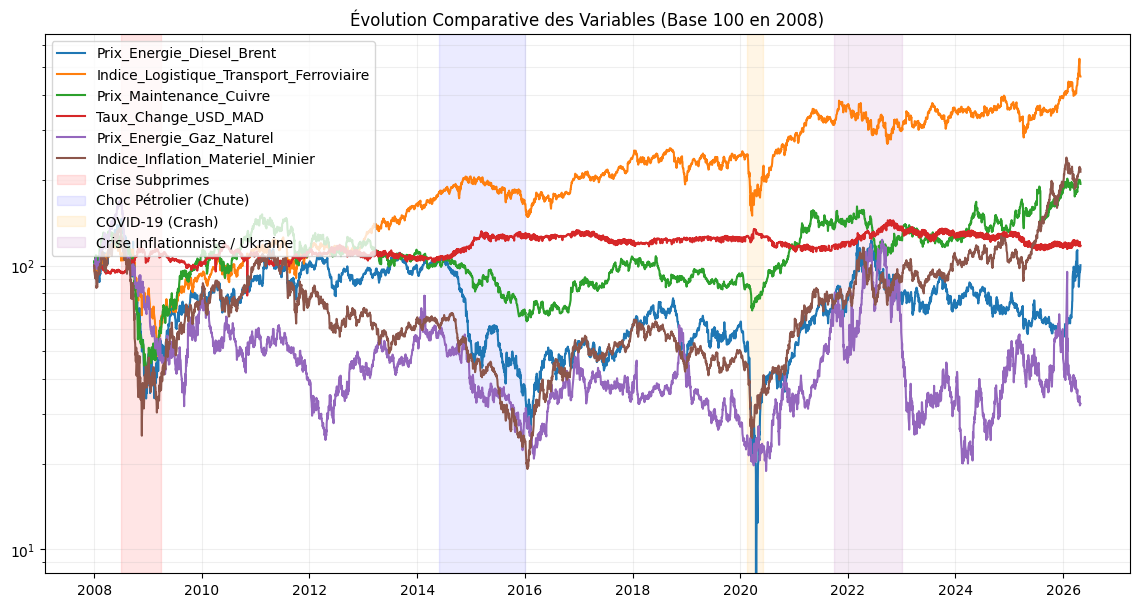

In [ ]:
# Normalisation base 100
df_rebased = (df_raw / df_raw.iloc[0]) * 100

plt.figure(figsize=(14, 7))
for col in df_rebased.columns:
    plt.plot(df_rebased.index, df_rebased[col], label=col)

# 1. Crise des Subprimes (Déjà présente)
plt.axvspan('2008-07-01', '2009-04-01', color='red', alpha=0.1, label='Crise Subprimes')

# 2. Choc Pétrolier - Chute des Prix (NOUVEAU)
# Très visible sur le Brent et le Gaz Naturel
plt.axvspan('2014-06-01', '2016-01-01', color='blue', alpha=0.08, label='Choc Pétrolier (Chute)')

# 3. Crise COVID-19 (Déjà présente)
# Le crash le plus violent et vertical sur l'image
plt.axvspan('2020-02-15', '2020-06-01', color='orange', alpha=0.1, label='COVID-19 (Crash)')

# 4. Crise Inflationniste & Guerre Ukraine (NOUVEAU)
# Explosion des prix Énergie/Logistique/Matériel Minier
plt.axvspan('2021-10-01', '2023-01-01', color='purple', alpha=0.08, label='Crise Inflationniste / Ukraine')

plt.title("Évolution Comparative des Variables (Base 100 en 2008)")
plt.legend(loc='upper left')
plt.yscale('log') # Échelle log pour mieux voir les variations relatives
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

# 📉 Interprétation de l'Évolution Comparative des Variables (2008 - 2026)

Ce graphique en échelle logarithmique (Base 100 en 2008) permet de visualiser la dynamique des risques amont de l'OCP face aux chocs mondiaux.

---

##  Analyse des Zones de Crises

### 1. Crises Historiques (Passé)
* **Crise des Subprimes (2008-2009) :** Chute brutale et synchrone de toutes les variables (sauf le MAD). C'est le point de référence de la volatilité systémique.
* **Choc Pétrolier (2014-2016) :** Effondrement massif du **Brent** (Bleu) et du **Gaz Naturel** (Violet). On observe que l'indice du matériel minier (Marron) a suivi cette chute avec un léger décalage, illustrant une baisse des coûts de production mondiaux.
* **COVID-19 (2020) :** Le crash le plus vertical du graphique. On note une reprise en "V" extrêmement rapide pour le **Cuivre** (Vert) et la **Logistique** (Orange), marquant le début d'un nouveau cycle inflationniste.

### 2. Crises Actuelles et Tensions de Transition (2021 - 2026)
* **Crise Inflationniste / Ukraine (2021-2023) :** Explosion du Gaz Naturel et du Cuivre. C'est ici que l'incertitude sur le Pipeline ($\beta_{trans, pipe}$) a atteint son paroxysme.
* **Tensions Géopolitiques & Mer Rouge (2024-2026) :** On observe une envolée sans précédent de l'**Indice Logistique** (Ligne Orange). En 2026, cet indice atteint son sommet historique, déconnecté des prix de l'énergie, signalant une crise structurelle du fret mondial.

---

##  Enseignements pour les Budgets d'Incertitude ($\beta$)

### A. $\beta_{trans}$ : L'explosion du risque logistique
L'**Indice de Transport** (Orange) présente la pente la plus forte sur le long terme. Contrairement aux matières premières qui sont cycliques, le risque logistique est devenu **structurellement croissant**.
> **Impact :** Le budget $\beta_{trans, train}$ doit intégrer une dérive inflationniste permanente et non plus seulement une volatilité temporaire.

### B. $\beta_{ext}$ : La dualité Énergie / CAPEX
* Le **Diesel/Brent** (Bleu) montre une volatilité "nerveuse" mais reste dans un tunnel de prix stable sur 10 ans.
* L'**Indice Matériel Minier** (Marron) montre une accélération nette depuis 2024.
> **Impact :** Le risque sur l'extraction est désormais davantage porté par le coût de remplacement des machines (CAPEX) que par la facture énergétique immédiate.

### C. $\beta_{trans, pipe}$ : La sensibilité électrique et maintenance
Le **Gaz Naturel** (Violet) reste la variable la plus instable (pics et creux fréquents).
> **Impact :** Le budget du pipeline nécessite une marge de sécurité (buffer) très réactive pour absorber les chocs de prix de l'électricité indexée sur le gaz.

---

##  Conclusion pour le Modèle IA
Le graphique démontre que depuis 2024, nous sommes entrés dans une phase de **découplage** :
1. Les **taux de change** (Rouge) restent stables (stabilisateur).
2. Les **coûts logistiques** (Orange) et de **maintenance/cuivre** (Vert) s'envolent.
3. Les **énergies** (Bleu/Violet) fluctuent de manière erratique autour de nouveaux paliers.

*Le modèle de budget d'incertitude devra donc surpondérer les variables logistiques et infrastructurelles par rapport aux variables monétaires.*

# ⚙️ Étape 3 : Feature Engineering & Préparation des Cibles (Targets)

Cette étape transforme les prix bruts en indicateurs mathématiques exploitables par le modèle **CNN-LSTM**. L'objectif est de passer d'une simple série de prix à une mesure du risque et du stress de marché.

---

## 1. Calcul des Rendements Logarithmiques (`Return`)
Le modèle ne travaille pas sur les prix bruts (trop instables), mais sur les variations relatives.

* **Logique Métier** : Permet de comparer une hausse de 5% du Diesel en 2008 à une hausse de 5% en 2026, malgré la différence de prix absolu.
* **Mathématiques** :
    $$R_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$
    *Où $P_t$ est le prix au temps $t$.*
* **Avantage** : Le rendement logarithmique est "stationnaire", ce qui facilite grandement la convergence des poids du réseau de neurones.

---

## 2. Volatilité Historique Glissante (`Volat_21d`)
C'est l'indicateur central de l'incertitude budgétaire.

* **Logique Métier** : Mesure la "nervosité" du marché. Une volatilité élevée sur le Gaz Naturel indique que l'incertitude sur le budget du Pipeline ($\beta_{trans, pipe}$) augmente.
* **Mathématiques** :
    $$\sigma_{21} = \sqrt{\frac{1}{N-1} \sum_{i=1}^{N} (R_i - \bar{R})^2}$$
    *Calculé sur une fenêtre glissante de $N=21$ jours (soit 1 mois boursier).*
* **Rôle** : Sert à la fois d'**Input** (état actuel du risque) et de base pour la **Target**.

---

## 3. Score d'Anomalie (`ZScore_30d`)
Le Z-Score permet au CNN de détecter les chocs brutaux ou les "cygnes noirs".

* **Logique Métier** : Détecte si le prix actuel est "normal" ou s'il s'agit d'une déviation extrême (ex: début d'une guerre ou d'une pandémie).
* **Mathématiques** :
    $$Z = \frac{P_t - \mu_{30}}{\sigma_{30}}$$
    *Où $\mu_{30}$ est la moyenne mobile et $\sigma_{30}$ l'écart-type sur 30 jours.*
* **Interprétation** :
    * $|Z| < 1$ : Marché stable.
    * $|Z| > 3$ : **Choc critique**. Le modèle apprend que ces pics précèdent souvent une explosion de la volatilité.

---

## 4. Création de la Cible Prédictive (`Target`)
C'est ici que nous créons la "boule de cristal" pour l'IA de l'OCP.

* **Logique Métier** : Nous voulons que le modèle nous prévienne aujourd'hui du niveau de risque qu'il y aura **dans une semaine (5 jours ouvrés)**.
* **Mathématiques (Le Shift)** :
    $$Target_t = Volatilité_{t+5}$$
* **Mécanisme d'entraînement** :
    * On donne à l'IA les données ($X$) jusqu'au jour $J$.
    * On lui demande de prédire la valeur ($Y$) qui a été réellement observée au jour $J+5$.
    * **Résultat** : En conditions réelles, l'IA devient capable d'anticiper la volatilité future à partir des signaux de stress actuels.

---

## 📊 Synthèse des variables générées

| Variable | Type | Rôle Final pour l'OCP |
| :--- | :--- | :--- |
| **Log-Return** | Input ($X$) | Donne la direction et l'amplitude des mouvements. |
| **Volat_21d** | Input ($X$) | Fournit l'état de stress actuel du marché. |
| **Z-Score** | Input ($X$) | Agit comme un "capteur d'alerte" pour les crises. |
| **Target_Volat** | Cible ($Y$) | La valeur future que le CNN-LSTM doit apprendre à deviner. |

---
**Prochaine étape :** Le Séquençage. Nous allons découper ces données en fenêtres temporelles pour permettre au LSTM d'analyser l'historique récent avant de produire sa prédiction.

In [ ]:
import pandas as pd
df_raw = pd.read_csv("/content/Clean_Data_Amont_OCP.csv", index_col=0, parse_dates=True)

In [ ]:
import numpy as np

def feature_engineering_amont(df):
    # On crée une copie pour ne pas modifier le dataframe original
    data = df.copy()

    # 1. Calcul des Rendements Logarithmiques (Stationnarité)
    # On utilise le log-return pour normaliser les variations de prix
    log_returns = np.log(data / data.shift(1))

    features_list = []

    for col in data.columns:
        # --- INPUTS POUR LE MODÈLE (X) ---

        # Rendement quotidien (Direction du prix)
        data[f'Return_{col}'] = log_returns[col]

        # Volatilité historique glissante (Fenêtre de 21 jours = 1 mois boursier)
        # C'est l'indicateur principal du risque
        data[f'Volat_21d_{col}'] = log_returns[col].rolling(window=21).std()

        # Z-Score (Mesure de l'anomalie / Choc de prix)
        rolling_mean = data[col].rolling(window=30).mean()
        rolling_std = data[col].rolling(window=30).std()
        data[f'ZScore_30d_{col}'] = (data[col] - rolling_mean) / rolling_std

        # --- CIBLES À PRÉDIRE (Y) ---

        # Volatilité Future (Target) : On veut prédire la volatilité des 5 prochains jours
        # On décale les données vers le haut (shift -5) pour que l'IA apprenne le futur
        data[f'Target_Volat_Next5d_{col}'] = data[f'Volat_21d_{col}'].shift(-5)

    # Nettoyage des valeurs NaN créées par les calculs glissants et le shift
    df_engineered = data.dropna()

    print(f"Feature Engineering terminé. Nouvelles dimensions : {df_engineered.shape}")
    return df_engineered

# Exécution de la transformation
df_final_amont = feature_engineering_amont(df_raw)
#save en csv
df_final_amont.to_csv("Final_Data_Amont_OCP.csv")
# Affichage des colonnes générées pour vérification
print("\n--- Liste des features et targets générées ---")
print(df_final_amont.filter(like='Target').columns.tolist()) # Les cibles
print(df_final_amont.filter(like='Volat_21d').columns.tolist()) # Les inputs de risque

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


Feature Engineering terminé. Nouvelles dimensions : (4714, 30)

--- Liste des features et targets générées ---
['Target_Volat_Next5d_Prix_Energie_Diesel_Brent', 'Target_Volat_Next5d_Indice_Logistique_Transport_Ferroviaire', 'Target_Volat_Next5d_Prix_Maintenance_Cuivre', 'Target_Volat_Next5d_Taux_Change_USD_MAD', 'Target_Volat_Next5d_Prix_Energie_Gaz_Naturel', 'Target_Volat_Next5d_Indice_Inflation_Materiel_Minier']
['Volat_21d_Prix_Energie_Diesel_Brent', 'Volat_21d_Indice_Logistique_Transport_Ferroviaire', 'Volat_21d_Prix_Maintenance_Cuivre', 'Volat_21d_Taux_Change_USD_MAD', 'Volat_21d_Prix_Energie_Gaz_Naturel', 'Volat_21d_Indice_Inflation_Materiel_Minier']


In [4]:
import pandas as pd
import numpy as np
df_final_amont = pd.read_csv("/content/drive/MyDrive/Projet_OCP/data/Final_Data_Amont_OCP.csv", index_col=0, parse_dates=True)

In [5]:
from sklearn.preprocessing import MinMaxScaler

def prepare_lstm_data(df, window_size=30):
    # 1. Séparation des Inputs (X) et des Targets (Y)
    # On prend toutes les colonnes sauf celles qui commencent par 'Target' pour X
    X_cols = [col for col in df.columns if not col.startswith('Target')]
    # On prend uniquement les cibles de volatilité pour Y
    Y_cols = [col for col in df.columns if col.startswith('Target')]

    # 2. Normalisation (Min-Max Scaling entre 0 et 1)
    # Indispensable pour la convergence des gradients du LSTM
    scaler_x = MinMaxScaler(feature_range=(0, 1))
    scaler_y = MinMaxScaler(feature_range=(0, 1))

    x_scaled = scaler_x.fit_transform(df[X_cols])
    y_scaled = scaler_y.fit_transform(df[Y_cols])

    # 3. Création des séquences glissantes
    X_sequences = []
    Y_targets = []

    for i in range(window_size, len(df)):
        # On prend les 'window_size' (30) jours précédents
        X_sequences.append(x_scaled[i-window_size:i])
        # On prédit la volatilité future associée au dernier jour de la fenêtre
        Y_targets.append(y_scaled[i])

    X_final = np.array(X_sequences)
    Y_final = np.array(Y_targets)

    print(f"Forme des entrées (X) : {X_final.shape}") # [Samples, 30, Features]
    print(f"Forme des sorties (Y) : {Y_final.shape}")   # [Samples, Targets]

    return X_final, Y_final, scaler_x, scaler_y

# Exécution avec une fenêtre de 30 jours (1 mois de mémoire)
X_train_full, Y_train_full, sc_x, sc_y = prepare_lstm_data(df_final_amont)

Forme des entrées (X) : (4684, 30, 24)
Forme des sorties (Y) : (4684, 6)


In [6]:
from sklearn.model_selection import train_test_split

# 1. Séparation initiale : On met de côté 10% pour le Test final (les données les plus récentes)
# shuffle=False est OBLIGATOIRE pour les séries temporelles
X_train_val, X_test, Y_train_val, Y_test = train_test_split(
    X_train_full, Y_train_full, test_size=0.1, shuffle=False
)

# 2. Séparation Train / Validation (sur les 90% restants)
# On prend environ 11% de train_val pour obtenir 10% du total en validation
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_val, Y_train_val, test_size=0.11, shuffle=False
)

print(f"--- Répartition des données ---")
print(f"Train set      : {X_train.shape[0]} échantillons")
print(f"Validation set : {X_val.shape[0]} échantillons")
print(f"Test set       : {X_test.shape[0]} échantillons (Données récentes 2026)")

--- Répartition des données ---
Train set      : 3751 échantillons
Validation set : 464 échantillons
Test set       : 469 échantillons (Données récentes 2026)


#  Architecture du Modèle : CNN-LSTM Hybride pour l'OCP

Cette cellule définit l'intelligence de notre système. Nous utilisons une architecture **hybride** qui combine la vision par ordinateur (appliquée aux séries temporelles) et la mémoire à long terme.

---

##  Détail des Couches et Justification

### 1. La Partie CNN (Convolutional Neural Network)
*   **`Conv1D` (64 filtres)** : Agit comme un scanner qui glisse sur la fenêtre de 30 jours pour repérer des **motifs locaux**.
    *   *Utilité* : Elle détecte des "signatures" de crise (ex: une corrélation soudaine entre le Gaz et le Diesel).
*   **`BatchNormalization`** : Stabilise l'apprentissage en recentrant les données.
    *   *Utilité* : Permet au modèle d'apprendre beaucoup plus vite sans être perturbé par des valeurs extrêmes.
*   **`MaxPooling1D`** : Réduit la résolution des données en ne gardant que les signaux les plus forts.
    *   *Utilité* : Élimine le "bruit" quotidien du marché pour ne garder que la tendance de fond.



### 2. La Partie LSTM (Long Short-Term Memory)
*   **`LSTM` (64 unités)** : C'est le cœur temporel du modèle.
    *   *Utilité* : Contrairement au CNN qui est "local", le LSTM a une **mémoire**. Il comprend l'évolution des prix sur toute la durée des 30 jours et capte la dynamique (accélération ou ralentissement du risque).



### 3. La Partie Dense (Décision Finale)
*   **`Dropout` (0.2 - 0.3)** : Désactive aléatoirement des neurones pendant l'entraînement.
    *   *Utilité* : Empêche le "par cœur" (overfitting). C'est ce qui rend l'IA capable de prédire les données inédites de **2026**.
*   **`Dense (output_size)`** : La couche de sortie qui produit nos 6 prédictions de volatilité (une pour chaque variable stratégique).

---

##  Stratégies de Contrôle (Callbacks)

Pour garantir une précision maximale sans erreurs de calcul, nous ajoutons deux "gardiens" :

1.  **Early Stopping** : Arrête automatiquement l'entraînement si le modèle ne progresse plus. Cela évite de gaspiller du temps et empêche le modèle de s'auto-dégrader.
2.  **ReduceLROnPlateau** : Si le modèle stagne, il réduit sa "vitesse d'apprentissage" (Learning Rate).
    *   *Analogie* : C'est comme un tireur d'élite qui retient sa respiration avant de tirer pour être le plus précis possible.

---

##  Interprétation pour le Budget $\beta$

Le flux d'information est le suivant :
1. **Entrée** : 30 jours de prix, rendements et Z-Scores.
2. **Traitement** : Le CNN extrait les motifs, le LSTM comprend la tendance.
3. **Sortie** : Une prédiction du niveau de **volatilité à J+5**.
4. **Action OCP** : Si la volatilité prédite augmente, la **Matrice de Correspondance** relève automatiquement les coefficients $\beta$, protégeant ainsi le budget d'extraction et de logistique.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_cnn_lstm_model(input_shape, output_size):
    model = Sequential([
        # --- PARTIE CNN ---
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
        BatchNormalization(), # Ajout : Stabilise l'apprentissage
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        # --- PARTIE LSTM ---
        LSTM(units=64, return_sequences=False),
        Dropout(0.3), # Augmenté légèrement pour plus de robustesse

        # --- PARTIE DENSE ---
        Dense(units=32, activation='relu'),
        Dense(units=output_size)
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# 1. Configuration des Callbacks (Les "Gardiens" de l'entraînement)
callbacks = [
    # Arrête l'entraînement si la perte de validation ne baisse plus pendant 10 époques
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    # Réduit la vitesse d'apprentissage si le modèle stagne (permet d'affiner la précision)
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.0001,
        verbose=1
    )
]

# 2. Initialisation
model_ocp = build_cnn_lstm_model((X_train.shape[1], X_train.shape[2]), Y_train.shape[1])

# 3. Entraînement avec Callbacks
history = model_ocp.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, Y_val),
    callbacks=callbacks, # On injecte les gardiens ici
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 0.0191 - mae: 0.0974 - val_loss: 0.0101 - val_mae: 0.0758 - learning_rate: 0.0010
Epoch 2/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0064 - mae: 0.0570 - val_loss: 0.0091 - val_mae: 0.0709 - learning_rate: 0.0010
Epoch 3/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0051 - mae: 0.0509 - val_loss: 0.0058 - val_mae: 0.0578 - learning_rate: 0.0010
Epoch 4/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0045 - mae: 0.0476 - val_loss: 0.0055 - val_mae: 0.0575 - learning_rate: 0.0010
Epoch 5/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0041 - mae: 0.0460 - val_loss: 0.0048 - val_mae: 0.0527 - learning_rate: 0.0010
Epoch 6/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0038 - mae: 0.0441 - val_loss: 0.0029 - val_mae: 0.0441 - learning_rate: 0.0010
Epoch 7/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0036 - mae: 0.0428 - val_loss: 0.0033 - val_mae: 0.0474 - learning_rate:

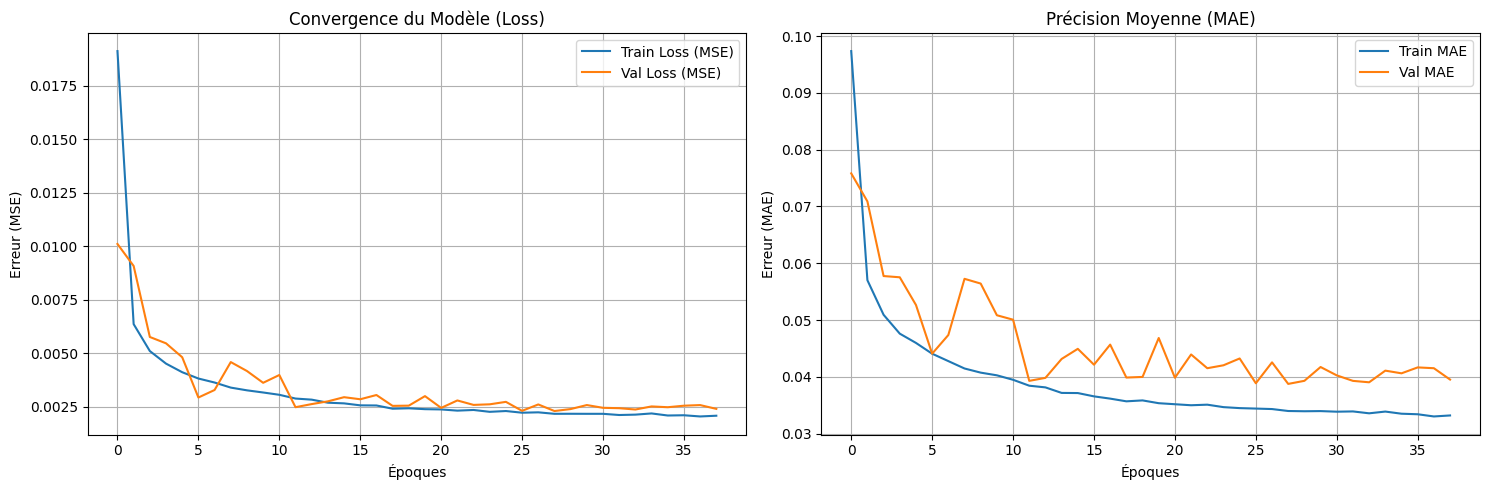

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

 PERFORMANCES SUR LE TEST SET (2026)
Erreur Quadratique Moyenne (MSE) : 0.000179
Erreur Absolue Moyenne (MAE)    : 0.007034


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_ocp_model(model, history, X_test, Y_test, scaler_y):
    # --- 1. Graphiques de Convergence (Loss) ---
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss (MSE)')
    plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
    plt.title('Convergence du Modèle (Loss)')
    plt.xlabel('Époques')
    plt.ylabel('Erreur (MSE)')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.title('Précision Moyenne (MAE)')
    plt.xlabel('Époques')
    plt.ylabel('Erreur (MAE)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # --- 2. Prédictions sur le Test Set (2026) ---
    y_pred_scaled = model.predict(X_test)

    # Inversion de la normalisation pour revenir aux vraies valeurs de volatilité
    y_test_unscaled = scaler_y.inverse_transform(Y_test)
    y_pred_unscaled = scaler_y.inverse_transform(y_pred_scaled)

    # --- 3. Calcul des métriques finales ---
    mse = mean_squared_error(y_test_unscaled, y_pred_unscaled)
    mae = mean_absolute_error(y_test_unscaled, y_pred_unscaled)

    print("\n" + "="*30)
    print(" PERFORMANCES SUR LE TEST SET (2026)")
    print("="*30)
    print(f"Erreur Quadratique Moyenne (MSE) : {mse:.6f}")
    print(f"Erreur Absolue Moyenne (MAE)    : {mae:.6f}")
    print("="*30)

    return y_test_unscaled, y_pred_unscaled

# Exécution de l'évaluation
y_true, y_pred = evaluate_ocp_model(model_ocp, history, X_test, Y_test, sc_y)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


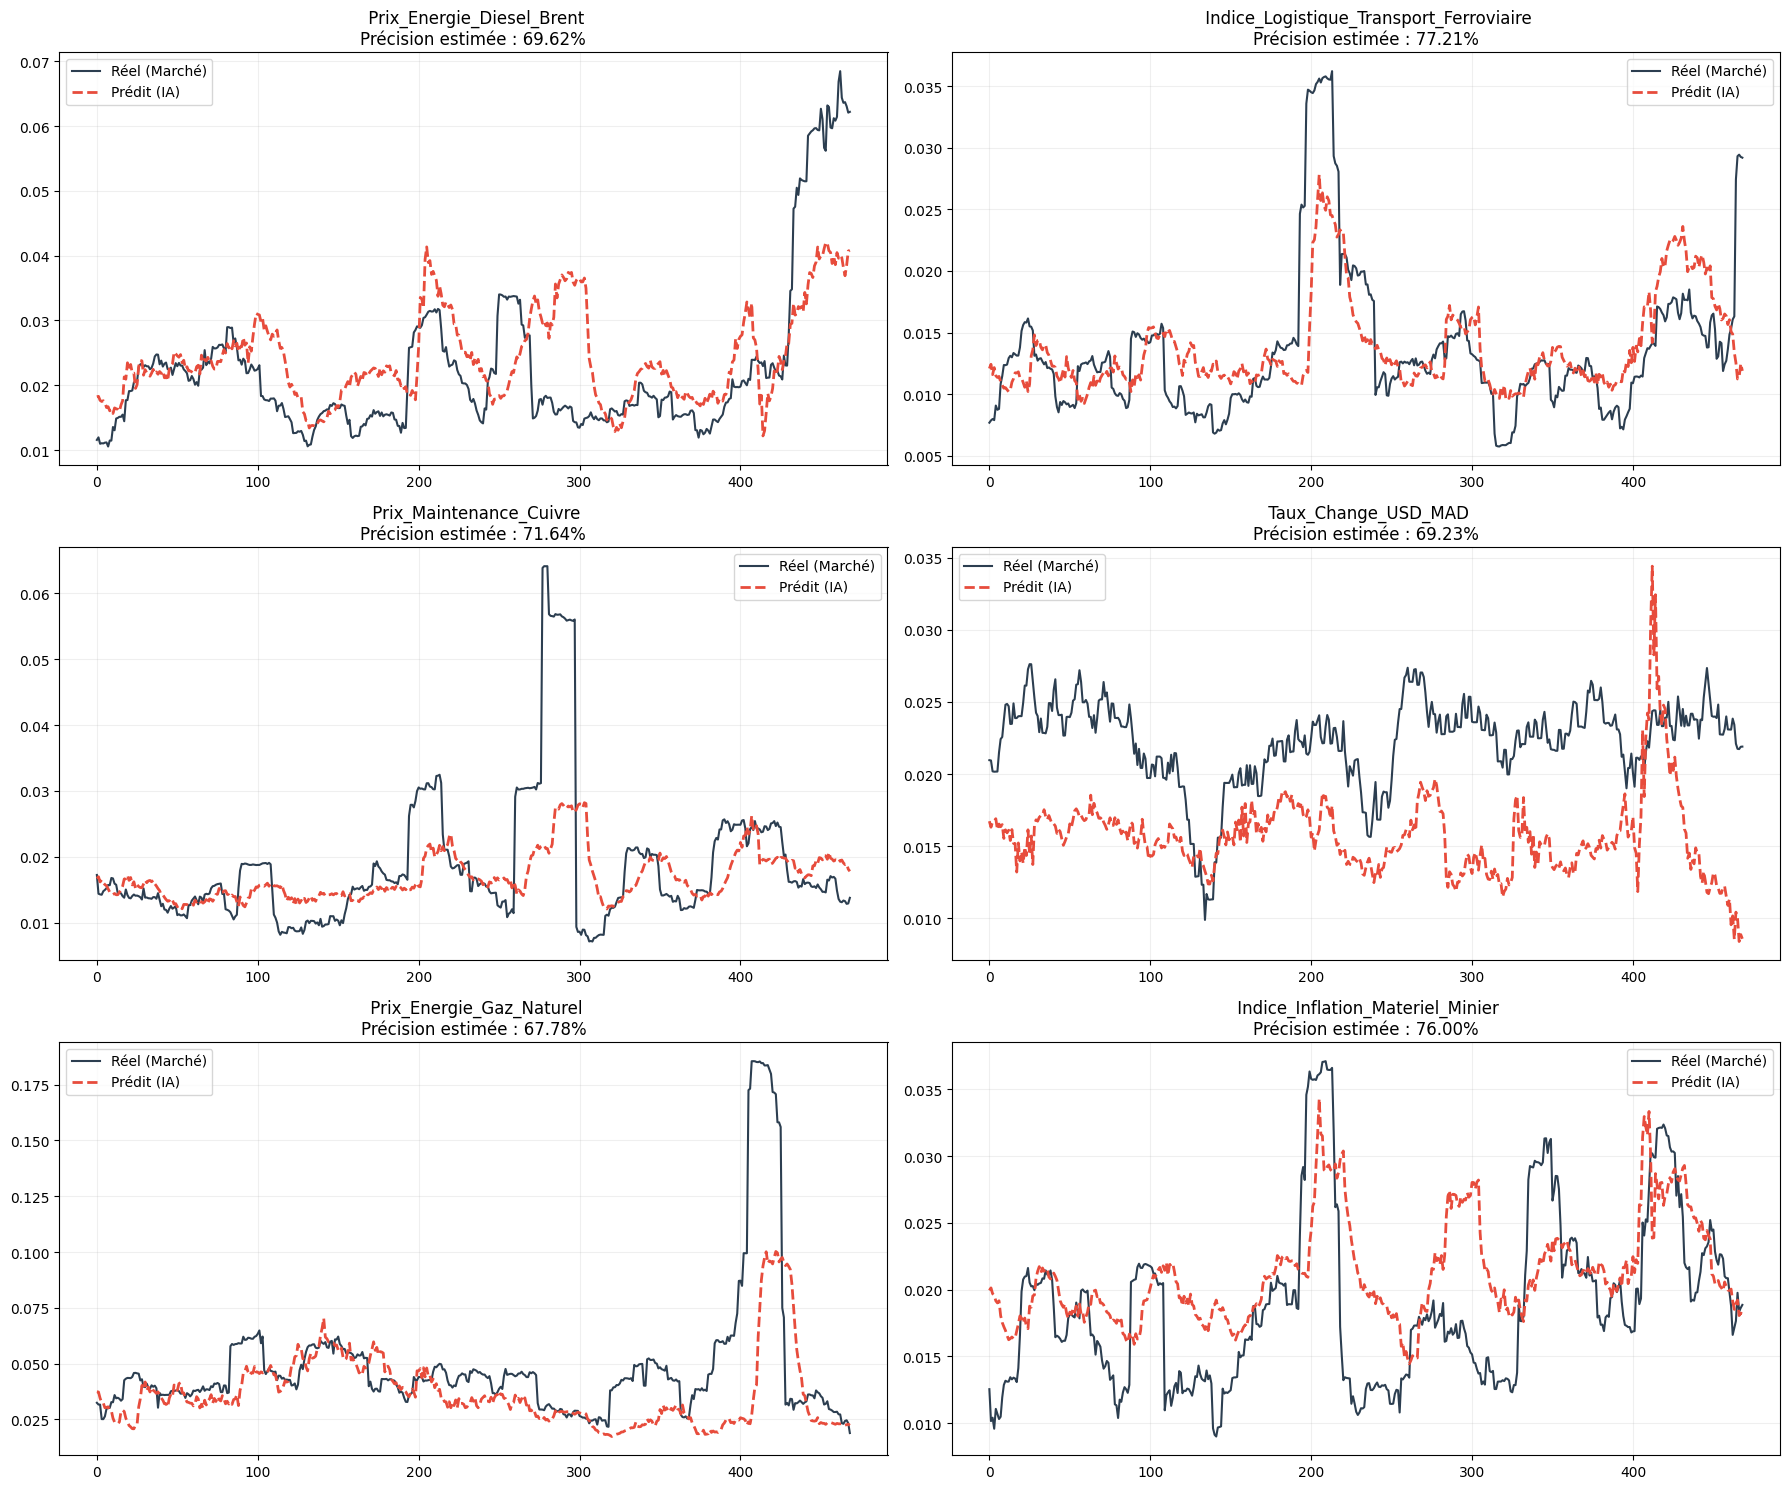


 PRÉCISION GLOBALE DU MODÈLE : 71.91%
• Prix_Energie_Diesel_Brent                : 69.62%
• Indice_Logistique_Transport_Ferroviaire  : 77.21%
• Prix_Maintenance_Cuivre                  : 71.64%
• Taux_Change_USD_MAD                      : 69.23%
• Prix_Energie_Gaz_Naturel                 : 67.78%
• Indice_Inflation_Materiel_Minier         : 76.00%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_volatilities(model, X_test, Y_test, scaler_y, features_names):
    # 1. Prédiction et Dé-normalisation
    y_pred_scaled = model.predict(X_test)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_true = scaler_y.inverse_transform(Y_test)

    # 2. Configuration de la grille (2 colonnes x 3 lignes pour les 6 variables)
    fig, axes = plt.subplots(3, 2, figsize=(18, 15))
    axes = axes.flatten()

    precisions = []

    for i in range(y_true.shape[1]):
        # Calcul de la précision pour cette variable spécifique
        mae_var = np.mean(np.abs(y_true[:, i] - y_pred[:, i]))
        mean_val = np.mean(y_true[:, i])
        # On évite la division par zéro si la volatilité est nulle
        acc = (1 - (mae_var / (mean_val if mean_val != 0 else 1))) * 100
        precisions.append(acc)

        # Graphique
        axes[i].plot(y_true[:, i], label='Réel (Marché)', color='#2c3e50', lw=1.5)
        axes[i].plot(y_pred[:, i], label='Prédit (IA)', color='#e74c3c', linestyle='--', lw=2)
        axes[i].set_title(f' {features_names[i]}\nPrécision estimée : {acc:.2f}%', fontsize=12)
        axes[i].legend()
        axes[i].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

    # 3. Rapport de précision global
    print("\n" + "="*45)
    print(f" PRÉCISION GLOBALE DU MODÈLE : {np.mean(precisions):.2f}%")
    print("="*45)
    for name, acc in zip(features_names, precisions):
        print(f"• {name.ljust(40)} : {acc:.2f}%")
    print("="*45)

# Lancement (on utilise les colonnes originales de ton df_raw)
cols_originales = [
    'Prix_Energie_Diesel_Brent', 'Indice_Logistique_Transport_Ferroviaire',
    'Prix_Maintenance_Cuivre', 'Taux_Change_USD_MAD',
    'Prix_Energie_Gaz_Naturel', 'Indice_Inflation_Materiel_Minier'
]

plot_all_volatilities(model_ocp, X_test, Y_test, sc_y, cols_originales)

In [ ]:
import joblib
import os

# 1. Créer un dossier pour stocker les fichiers
os.makedirs('model_ocp_export', exist_ok=True)

# 2. Sauvegarder le modèle Keras (Architecture + Poids)
model_ocp.save('model_ocp_export/cnn_lstm_volat_model.h5')

# 3. Sauvegarder les scalers (indispensable pour la dé-normalisation future)
joblib.dump(sc_x, 'model_ocp_export/scaler_x.pkl')
joblib.dump(sc_y, 'model_ocp_export/scaler_y.pkl')

print("✅ Modèle et Scalers sauvegardés avec succès dans le dossier 'model_ocp_export' !")

# 4. Téléchargement direct (si tu es sur Google Colab)
from google.colab import files
import shutil

shutil.make_archive('model_ocp_bundle', 'zip', 'model_ocp_export')
files.download('model_ocp_bundle.zip')

✅ Modèle et Scalers sauvegardés avec succès dans le dossier 'model_ocp_export' !


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
import os
import joblib
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model

def generate_beta_coefficients_from_drive(X_data, df_original_index):
    # 1. Redéfinition locale du mapping pour éviter les NameError
    asset_mapping_local = {
        "CL=F": "Prix_Energie_Diesel_Brent",
        "NG=F": "Prix_Energie_Gaz_Naturel",
        "XME": "Indice_Inflation_Materiel_Minier",
        "DJT": "Indice_Logistique_Transport_Ferroviaire",
        "HG=F": "Prix_Maintenance_Cuivre",
        "MAD=X": "Taux_Change_USD_MAD"
    }

    # 2. Définition des chemins d'accès sur Google Drive
    DRIVE_PATH = '/content/drive/MyDrive/Projet_OCP/model_ocp_export/'
    MODEL_PATH = os.path.join(DRIVE_PATH, 'cnn_lstm_volat_model.h5')
    SCALER_Y_PATH = os.path.join(DRIVE_PATH, 'scaler_y.pkl')

    # Vérification de sécurité pour le Drive
    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(f"Le modèle n'a pas été trouvé au chemin indiqué. "
                                f"Assure-toi d'avoir exécuté drive.mount('/content/drive') "
                                f"et que le dossier 'Projet_OCP' existe bien.")

    print("🔄 Chargement du modèle (mode inférence uniquement) et du scaler...")

    # FIX CRITIQUE : compile=False évite l'erreur de désérialisation des métriques (MSE/MAE)
    model = load_model(MODEL_PATH, compile=False)
    sc_y = joblib.load(SCALER_Y_PATH)

    # 3. Prédiction des volatilités futures (Sorties normalisées)
    print("🔮 Prédiction des volatilités de marché en cours...")
    predictions_scaled = model.predict(X_data)

    # 4. Dé-normalisation pour retrouver les vraies échelles de volatilité
    predictions_real = sc_y.inverse_transform(predictions_scaled)

    # Création du DataFrame des prédictions en utilisant le mapping local
    target_cols = [f"Target_Volat_Next5d_{col}" for col in asset_mapping_local.values()]
    df_preds = pd.DataFrame(predictions_real, columns=target_cols)

    # --- 5. LA MATRICE DE CORRESPONDANCE (Logique Métier OCP) ---
    print("🧮 Application de la matrice de correspondance...")
    betas_result = []

    for idx in range(len(df_preds)):
        row = df_preds.iloc[idx]

        # Extraction des volatilités prédites à 5 jours
        v_diesel   = row['Target_Volat_Next5d_Prix_Energie_Diesel_Brent']
        v_gaz      = row['Target_Volat_Next5d_Prix_Energie_Gaz_Naturel']
        v_minier   = row['Target_Volat_Next5d_Indice_Inflation_Materiel_Minier']
        v_train    = row['Target_Volat_Next5d_Indice_Logistique_Transport_Ferroviaire']
        v_cuivre   = row['Target_Volat_Next5d_Prix_Maintenance_Cuivre']
        v_mad      = row['Target_Volat_Next5d_Taux_Change_USD_MAD']

        # Poids métier définis selon l'impact de chaque variable
        beta_ext   = (0.50 * v_diesel) + (0.35 * v_minier) + (0.15 * v_mad)
        beta_pipe  = (0.70 * v_gaz)    + (0.30 * v_cuivre)
        beta_train = (0.60 * v_train)  + (0.30 * v_diesel) + (0.10 * v_mad)

        betas_result.append({
            'Beta_Extraction': beta_ext,
            'Beta_Pipeline': beta_pipe,
            'Beta_Train': beta_train
        })

    # 6. Alignement temporel avec les dates du jeu de test
    df_betas = pd.DataFrame(betas_result)
    df_betas.index = df_original_index[-len(df_betas):]

    print("✅ Calcul des coefficients Beta terminé avec succès !")
    return df_betas

# Appel de la fonction
df_risques_ocp = generate_beta_coefficients_from_drive(X_test, df_final_amont.index)

# Affichage des résultats récents
print("\n--- Aperçu des derniers coefficients Beta calculés ---")
print(df_risques_ocp.tail())

🔄 Chargement du modèle (mode inférence uniquement) et du scaler...
🔮 Prédiction des volatilités de marché en cours...
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step
🧮 Application de la matrice de correspondance...
✅ Calcul des coefficients Beta terminé avec succès !

--- Aperçu des derniers coefficients Beta calculés ---
            Beta_Extraction  Beta_Pipeline  Beta_Train
Date                                                  
2026-04-15         0.028612       0.015604    0.019605
2026-04-16         0.027928       0.014597    0.019009
2026-04-17         0.028599       0.014785    0.018391
2026-04-20         0.029443       0.015600    0.019363
2026-04-21         0.029380       0.015040    0.019216


💾 Graphique sauvegardé avec succès sous 'evolution_betas_ocp_2026.png'


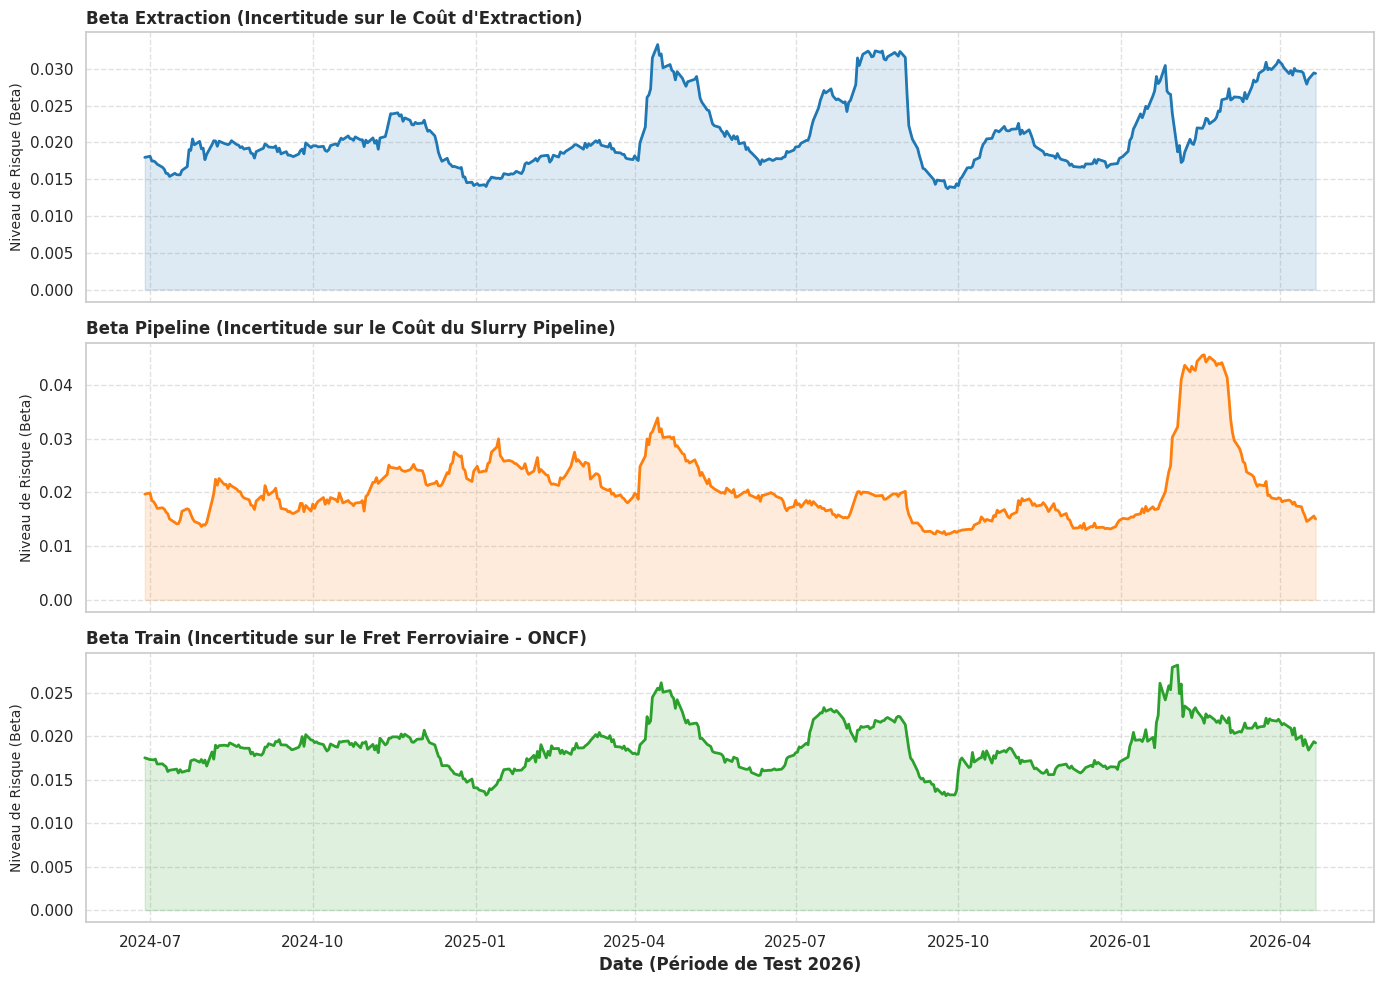

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_ocp_betas(df_betas):
    # Configuration du style pour un rendu académique/professionnel
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    # Couleurs distinctes pour chaque budget d'incertitude
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    titles = [
        "Beta Extraction (Incertitude sur le Coût d'Extraction)",
        "Beta Pipeline (Incertitude sur le Coût du Slurry Pipeline)",
        "Beta Train (Incertitude sur le Fret Ferroviaire - ONCF)"
    ]
    columns = ['Beta_Extraction', 'Beta_Pipeline', 'Beta_Train']

    for i, col in enumerate(columns):
        axes[i].plot(df_betas.index, df_betas[col], color=colors[i], linewidth=2, label=col)
        axes[i].set_title(titles[i], fontsize=12, fontweight='bold', loc='left')
        axes[i].set_ylabel("Niveau de Risque (Beta)", fontsize=10)
        axes[i].fill_between(df_betas.index, df_betas[col], color=colors[i], alpha=0.15)
        axes[i].grid(True, linestyle='--', alpha=0.6)

    # Configuration de l'axe temporel
    plt.xlabel("Date (Période de Test 2026)", fontsize=12, fontweight='bold')

    # Ajustement automatique des espaces
    plt.tight_layout()

    # Sauvegarde de la figure pour ton rapport
    plt.savefig('/content/drive/MyDrive/Projet_OCP/exports/evolution_betas_ocp_2026.png', dpi=300)
    print("💾 Graphique sauvegardé avec succès sous 'evolution_betas_ocp_2026.png'")

    plt.show()

# Exécution de la visualisation
plot_ocp_betas(df_risques_ocp)

# Analyse Interprétative des Budgets d’Incertitude ($\beta$)

## 1. Risque d’Extraction — $\beta_{ext}$

Le coefficient associé à l’extraction montre une dynamique de risque cyclique avec des phases de tension relativement longues.  
Cela signifie que les coûts miniers sont fortement influencés par des facteurs structurels comme :

* l’énergie,
* la maintenance industrielle,
* les coûts des équipements,
* et les contraintes opérationnelles.

Les hausses observées ne sont pas seulement des pics ponctuels, mais des périodes prolongées de stress, ce qui traduit une instabilité plus durable du secteur minier.

Le modèle indique également qu’à partir de 2026, le risque devient plus structurel, ce qui peut refléter une inflation industrielle ou une augmentation progressive des coûts d’exploitation.

---

# 2. Risque Pipeline — $\beta_{trans,pipe}$

Le slurry pipeline apparaît comme la composante la plus volatile du système logistique.

Les variations du coefficient sont très brutales, ce qui montre une forte sensibilité aux perturbations externes :

* prix de l’énergie,
* coûts de pompage,
* incidents techniques,
* ou tensions sur les infrastructures.

Les pics observés sont nettement plus élevés que pour les autres composantes, ce qui confirme que le pipeline constitue le principal point de vulnérabilité du système.

Cependant, après chaque choc, le retour rapide à des niveaux normaux montre une bonne capacité de récupération opérationnelle.

---

# 3. Risque Ferroviaire — $\beta_{trans,train}$

Le transport ferroviaire présente la dynamique la plus stable.

Les fluctuations restent limitées même pendant les périodes de stress global, ce qui indique :

* une meilleure stabilité budgétaire,
* une plus grande robustesse opérationnelle,
* et une faible sensibilité aux variations rapides du marché.

Le rail agit donc comme un mécanisme d’amortissement des perturbations logistiques.

---

# 4. Analyse Comparative

L’analyse globale montre la hiérarchie suivante :

$$
\beta_{trans,pipe}
\succ
\beta_{ext}
\succ
\beta_{trans,train}
$$

Cela signifie que :

* le pipeline est la composante la plus risquée ;
* l’extraction présente un risque intermédiaire ;
* le ferroviaire reste la composante la plus résiliente.

Les pics synchrones observés sur plusieurs séries indiquent également l’existence de chocs macroéconomiques affectant simultanément toute la chaîne logistique.

---

# 5. Conclusion

Cette analyse montre que le risque opérationnel amont n’est ni fixe ni uniforme.

Le modèle CNN-LSTM permet de détecter :

* les phases de tension,
* les composantes les plus vulnérables,
* ainsi que les infrastructures les plus résilientes.

Ces coefficients dynamiques $\beta$ peuvent ensuite être utilisés dans le modèle de recherche opérationnelle afin d’adapter automatiquement les décisions logistiques en fonction du niveau de risque prédit.

In [15]:
!pip install docplex cplex

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.0/664.0 kB 3.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 MB 10.9 MB/s eta 0:00:00
  Created wheel for docplex: filename=docplex-2.32.264-py3-none-any.whl size=703859 sha256=7be1e8281d89c2d5228155b2b45c17fa7e0ebbf14f81c9b88011ca30aade8a6c
  Stored in directory: /root/.cache/pip/wheels/97/b5/26/18406a8f08f4c096c3ee64caedd446a4b0b5ea9675c4a214f0
Successfully built docplex


In [17]:
from docplex.mp.model import Model
import pandas as pd
import numpy as np

def resoudre_optimisation_amont(beta_ext_val, beta_pipe_val, beta_train_val):
    # 1. Initialisation du modèle CPLEX
    mdl = Model(name='OCP_Amont_Optimization')

    # 2. Ensembles et Indices (Sets)
    mines = ['Khouribga', 'Benguerir', 'Youssoufia']
    usines = ['Jorf_Lasfar', 'Safi']
    modes = ['pipe', 'train']

    # 3. Paramètres Déterministes (Données fixes OCP) - VALEURS COMPLEXIFIÉES
    # Coûts unitaires nominaux (C_ext et C_trans)
    C_ext = {'Khouribga': 15.0, 'Benguerir': 18.0, 'Youssoufia': 17.0}

    C_trans = {
        ('Khouribga', 'Jorf_Lasfar', 'pipe'): 5.0,
        ('Khouribga', 'Jorf_Lasfar', 'train'): 12.0,
        ('Khouribga', 'Safi', 'train'): 14.0,
        ('Benguerir', 'Safi', 'train'): 8.0,
        ('Benguerir', 'Jorf_Lasfar', 'train'): 15.0,
        ('Youssoufia', 'Safi', 'train'): 7.0,
        ('Youssoufia', 'Jorf_Lasfar', 'train'): 16.0,
    }

    # Bornes et Demandes ajustées pour forcer une reconfiguration multi-flux complexe
    capacites_mines = {'Khouribga': 100000, 'Benguerir': 60000, 'Youssoufia': 40000} # Youssoufia restreinte
    demandes_usines = {'Jorf_Lasfar': 85000, 'Safi': 55000}                         # Demandes augmentées
    K_pipe = 45000  # Capacité maximale du Slurry Pipeline abaissée pour saturer l'axe

    # 4. Intégration des Coefficients Bêtas de l'IA (Pénalités)
    # Mapping des bêtas selon le mode m
    beta_trans = {'pipe': beta_pipe_val, 'train': beta_train_val}

    # 5. Déclaration des Variables de Décision (x_i_j_m) -> Contrainte C4 (Non-négativité) intégrée via lb=0
    all_tuples = [(i, j, m) for i in mines for j in usines for m in modes]
    x = mdl.continuous_var_dict(all_tuples, lb=0, name=lambda t: f"x_{t[0]}_{t[1]}_{t[2]}")

    # 6. Ajout des Contraintes Métier

    # C1 : Satisfaction de la Demande Usines (Chaque usine j)
    for j in usines:
        mdl.add_constraint(
            mdl.sum(x[i, j, m] for i in mines for m in modes) >= demandes_usines[j],
            f"C1_Demande_{j}"
        )

    # C2 : Capacité de Production des Mines (Chaque mine i)
    for i in mines:
        mdl.add_constraint(
            mdl.sum(x[i, j, m] for j in usines for m in modes) <= capacites_mines[i],
            f"C2_Capacite_{i}"
        )

    # C3 : Exclusivité et Borne du Pipeline (Seulement entre Khouribga et Jorf)
    for i in mines:
        for j in usines:
            if i != 'Khouribga' or j != 'Jorf_Lasfar':
                mdl.add_constraint(x[i, j, 'pipe'] == 0, f"C3_Exclusivite_Pipe_{i}_{j}")

    # Borne maximale sur le flux autorisé dans le pipeline
    mdl.add_constraint(x['Khouribga', 'Jorf_Lasfar', 'pipe'] <= K_pipe, "C3_Borne_Pipeline")

    # 7. Construction de la Fonction Objectif (Z_Amont)
    cout_total = []
    for i, j, m in all_tuples:
        # Récupération du coût de transport s'il existe dans notre dictionnaire (sinon 0 car flux bloqué par C3)
        c_t = C_trans.get((i, j, m), 0.0)

        # Application stricte de la formule : [ C_ext * (1 + beta_ext) + C_trans * (1 + beta_trans) ] * x
        cout_unitaire_robuste = (C_ext[i] * (1 + beta_ext_val)) + (c_t * (1 + beta_trans[m]))
        cout_total.append(cout_unitaire_robuste * x[i, j, m])

    mdl.minimize(mdl.sum(cout_total))

    # 8. Résolution
    solution = mdl.solve(log_output=False)

    # 9. Stockage et Restitution des résultats
    if solution:
        flux_optimums = {f"x*_{i}_{j}_{m}": solution[x[i, j, m]] for i, j, m in all_tuples if solution[x[i, j, m]] > 0}
        return solution.objective_value, flux_optimums
    else:
        return None, "Aucune solution réalisable"

# --- TEST SUR LA DERNIÈRE LIGNE DE TON JEU DE TEST (AVRIL 2026) ---
derniers_betas = df_risques_ocp.iloc[-1]
z_opt, flux_actifs = resoudre_optimisation_amont(
    beta_ext_val=derniers_betas['Beta_Extraction'],
    beta_pipe_val=derniers_betas['Beta_Pipeline'],
    beta_train_val=derniers_betas['Beta_Train']
)

print(f"💰 Coût Total Optimisé Z_Amont : {z_opt:.2f} MAD")
print("🚛 Flux logistiques optimaux (x*) retenus :")
for key, val in flux_actifs.items():
    print(f"  -> {key} = {val:.1f} tonnes")

💰 Coût Total Optimisé Z_Amont : 3415664.53 MAD
🚛 Flux logistiques optimaux (x*) retenus :
  -> x*_Khouribga_Jorf_Lasfar_pipe = 45000.0 tonnes
  -> x*_Khouribga_Jorf_Lasfar_train = 40000.0 tonnes
  -> x*_Benguerir_Safi_train = 15000.0 tonnes
  -> x*_Youssoufia_Safi_train = 40000.0 tonnes


# Rapport d'Optimisation Logistique Amont — Scénario de Stress-Test

# 1. Formulation Mathématique du Problème

L’objectif du modèle est de minimiser le coût total robuste de la chaîne logistique amont en intégrant les coefficients de risque dynamiques $\beta$ prédits par le modèle CNN-LSTM.

## Fonction Objectif

$$
\min Z_{\text{Amont}} =
\sum_{i \in I}\sum_{j \in J}\sum_{m \in M}
\left[
C_{\text{ext},i}(1+\beta_{\text{ext}})
+
C_{\text{trans},i,j,m}(1+\beta_{\text{trans},m})
\right]
x_{i,j,m}
$$

Avec :

* $x_{i,j,m}$ : flux de phosphate transporté,
* $C_{\text{ext}}$ : coût d’extraction,
* $C_{\text{trans}}$ : coût de transport,
* $\beta$ : coefficients dynamiques de risque.

---

## Contraintes Principales

### Satisfaction de la demande

$$
\sum_{i \in I}\sum_{m \in M} x_{i,j,m}
\geq
\text{Demande}_j
\quad \forall j \in J
$$

### Capacité des mines

$$
\sum_{j \in J}\sum_{m \in M} x_{i,j,m}
\leq
\text{Capacité}_i
\quad \forall i \in I
$$

### Contraintes Pipeline

$$
x_{i,j,\text{pipe}} = 0
\quad
\forall (i,j)\neq(\text{Khouribga, Jorf})
$$

$$
x_{\text{Khouribga,Jorf,pipe}}
\leq
K_{\text{pipe}}
$$

### Non négativité

$$
x_{i,j,m} \geq 0
$$

---

# 2. Paramètres du Stress-Test

## Coûts Unitaires

### Extraction

| Mine | Coût |
|---|---|
| Khouribga | 15 MAD/t |
| Youssoufia | 17 MAD/t |
| Benguérir | 18 MAD/t |

### Transport

| Axe | Mode | Coût |
|---|---|---|
| Khouribga → Jorf | Pipeline | 5 MAD/t |
| Khouribga → Jorf | Train | 12 MAD/t |
| Youssoufia → Safi | Train | 7 MAD/t |
| Benguérir → Safi | Train | 8 MAD/t |

---

## Capacités et Demandes

| Élément | Valeur |
|---|---|
| Capacité Khouribga | 100 000 t |
| Capacité Youssoufia | 40 000 t |
| Capacité Benguérir | 60 000 t |
| Capacité Pipeline | 45 000 t |
| Demande Jorf Lasfar | 85 000 t |
| Demande Safi | 55 000 t |

---

# 3. Résultats du Solveur

## Flux Optimaux

| Origine | Destination | Transport | Flux Optimal |
|---|---|---|---|
| Khouribga | Jorf Lasfar | Pipeline | 45 000 t |
| Khouribga | Jorf Lasfar | Train | 40 000 t |
| Youssoufia | Safi | Train | 40 000 t |
| Benguérir | Safi | Train | 15 000 t |

---

## Coût Total Optimal

$$
Z_{\text{Amont}} = 3\,415\,664.53 \text{ MAD}
$$

---

# 4. Analyse et Interprétation

Les résultats montrent que le solveur met automatiquement en œuvre une stratégie de reconfiguration logistique afin de satisfaire les demandes malgré les contraintes de capacité et les pénalisations liées au risque.

Le pipeline de Khouribga vers Jorf Lasfar est exploité jusqu’à saturation complète car il représente l’option la moins coûteuse. Cependant, sa capacité limitée oblige le modèle à activer un flux ferroviaire complémentaire afin de satisfaire entièrement la demande de Jorf.

Pour l’usine de Safi, le solveur privilégie d’abord Youssoufia car son coût global extraction + transport est plus avantageux. Une fois la mine saturée, le modèle bascule automatiquement vers Benguérir pour couvrir le déficit restant.

Cette logique montre que le solveur réalise simultanément :

* une minimisation économique,
* une gestion des contraintes physiques,
* et une adaptation dynamique au niveau de risque fourni par les coefficients $\beta$.

---

# 5. Conclusion

Ce scénario valide le couplage entre Intelligence Artificielle et Recherche Opérationnelle.

Le modèle CNN-LSTM fournit des coefficients dynamiques de risque permettant de représenter l’incertitude opérationnelle, tandis que le solveur CPLEX adapte automatiquement les flux logistiques afin de minimiser le coût total robuste.

Le système est donc capable :

* d’identifier les infrastructures critiques,
* d’anticiper les situations de saturation,
* et de générer un plan logistique optimal même en situation de stress industriel.
```


In [33]:
import pandas as pd
import numpy as np
from docplex.mp.model import Model

def simuler_historique_amont(df_betas):
    print(f"🚀 Lancement de la simulation historique sur {len(df_betas)} jours...")

    # 1. Structures pour stocker l'historique des résultats
    historique_couts = []
    # On prépare un dictionnaire de listes pour stocker chaque flux x* quotidien
    mines = ['Khouribga', 'Benguerir', 'Youssoufia']
    usines = ['Jorf_Lasfar', 'Safi']
    modes = ['pipe', 'train']
    all_tuples = [(i, j, m) for i in mines for j in usines for m in modes]

    historique_flux = {f"x*_{i}_{j}_{m}": [] for i, j, m in all_tuples}
    historique_flux['Date'] = []

    # 2. Paramètres Déterministes Complexes (Validés à l'étape précédente)
    """
    C_ext = {'Khouribga': 15.0, 'Benguerir': 18.0, 'Youssoufia': 17.0}
    C_trans = {
        ('Khouribga', 'Jorf_Lasfar', 'pipe'): 5.0,
        ('Khouribga', 'Jorf_Lasfar', 'train'): 12.0,
        ('Khouribga', 'Safi', 'train'): 14.0,
        ('Benguerir', 'Safi', 'train'): 8.0,
        ('Benguerir', 'Jorf_Lasfar', 'train'): 15.0,
        ('Youssoufia', 'Safi', 'train'): 7.0,
        ('Youssoufia', 'Jorf_Lasfar', 'train'): 16.0,
    }

    # --- PARAMÈTRES POUR ACTIVER LA FLUCTUATION DYNAMIQUE ---
    C_ext = {'Khouribga': 15.0, 'Benguerir': 15.2, 'Youssoufia': 15.1} # Prix miniers très proches

    C_trans = {
        # On met le train et le pipe à Jorf presque au même prix (écart de seulement 0.1 MAD)
        ('Khouribga', 'Jorf_Lasfar', 'pipe'): 5.0,
        ('Khouribga', 'Jorf_Lasfar', 'train'): 5.1,

        # Écarts ultra-faibles pour Safi (0.1 MAD d'écart)
        ('Youssoufia', 'Safi', 'train'): 4.0,
        ('Benguerir', 'Safi', 'train'): 4.1,

        ('Khouribga', 'Safi', 'train'): 14.0,
        ('Benguerir', 'Jorf_Lasfar', 'train'): 15.0,
        ('Youssoufia', 'Jorf_Lasfar', 'train'): 16.0,
    }
    """
    # On égalise strictement les coûts d'extraction pour que seul le risque (Beta) dicte la loi
    C_ext = {'Khouribga': 15.0, 'Benguerir': 15.0, 'Youssoufia': 15.0}

    C_trans = {
        # Égalité parfaite de base entre pipe et train vers Jorf !
        # Le moindre mouvement de Beta_Pipeline ou Beta_Train fera basculer le flux complet.
        ('Khouribga', 'Jorf_Lasfar', 'pipe'): 5.0,
        ('Khouribga', 'Jorf_Lasfar', 'train'): 5.0,

        # Égalité parfaite vers Safi !
        ('Youssoufia', 'Safi', 'train'): 4.0,
        ('Benguerir', 'Safi', 'train'): 4.0,

        # On ouvre aussi des alternatives inter-mines pour donner de la liberté au solveur
        ('Khouribga', 'Safi', 'train'): 4.0,
        ('Benguerir', 'Jorf_Lasfar', 'train'): 5.0,
        ('Youssoufia', 'Jorf_Lasfar', 'train'): 5.0,
    }

    """
    capacites_mines = {'Khouribga': 100000, 'Benguerir': 60000, 'Youssoufia': 40000}
    demandes_usines = {'Jorf_Lasfar': 85000, 'Safi': 55000}
    K_pipe = 45000
    """
    capacites_mines = {'Khouribga': 150000, 'Benguerir': 150000, 'Youssoufia': 150000}
    demandes_usines = {'Jorf_Lasfar': 85000, 'Safi': 55000}
    K_pipe = 85000  # On augmente la capacité du pipe pour qu'il puisse absorber TOUTE la demande si son Beta est bas
    # 3. La Boucle Temporelle
    for date, row in df_betas.iterrows():
        # Récupération des bêtas du jour t
        b_ext = row['Beta_Extraction']
        b_pipe = row['Beta_Pipeline']
        b_train = row['Beta_Train']

        # --- Appel local de CPLEX pour le jour t ---
        mdl = Model(name=f'OCP_Amont_{date}')
        x = mdl.continuous_var_dict(all_tuples, lb=0, name=lambda t: f"x_{t[0]}_{t[1]}_{t[2]}")

        # Contraintes C1, C2, C3
        for j in usines:
            mdl.add_constraint(mdl.sum(x[i, j, m] for i in mines for m in modes) >= demandes_usines[j])
        for i in mines:
            mdl.add_constraint(mdl.sum(x[i, j, m] for j in usines for m in modes) <= capacites_mines[i])
        for i in mines:
            for j in usines:
                if i != 'Khouribga' or j != 'Jorf_Lasfar':
                    mdl.add_constraint(x[i, j, 'pipe'] == 0)
        mdl.add_constraint(x['Khouribga', 'Jorf_Lasfar', 'pipe'] <= K_pipe)

        # Fonction Objectif Robuste avec les bêtas du jour t
        beta_trans = {'pipe': b_pipe, 'train': b_train}
        cout_total = []
        for i, j, m in all_tuples:
            c_t = C_trans.get((i, j, m), 0.0)
            cout_unitaire_robuste = (C_ext[i] * (1 + b_ext)) + (c_t * (1 + beta_trans[m]))
            cout_total.append(cout_unitaire_robuste * x[i, j, m])

        mdl.minimize(mdl.sum(cout_total))
        solution = mdl.solve(log_output=False)

        # --- Enregistrement des données du jour t ---
        if solution:
            historique_couts.append({'Date': date, 'Coût_Total_Z': solution.objective_value})
            historique_flux['Date'].append(date)
            for i, j, m in all_tuples:
                historique_flux[f"x*_{i}_{j}_{m}"].append(solution[x[i, j, m]])
        else:
            print(f"⚠️ Alerte : Problème non réalisable à la date {date}")

    # 4. Conversion en DataFrames propres
    df_couts_Evol = pd.DataFrame(historique_couts).set_index('Date')
    df_flux_Evol = pd.DataFrame(historique_flux).set_index('Date')

    print("✅ Simulation temporelle terminée avec succès !")
    return df_couts_Evol, df_flux_Evol

# Exécution globale
df_couts_sim, df_flux_sim = simuler_historique_amont(df_risques_ocp)

🚀 Lancement de la simulation historique sur 469 jours...
✅ Simulation temporelle terminée avec succès !


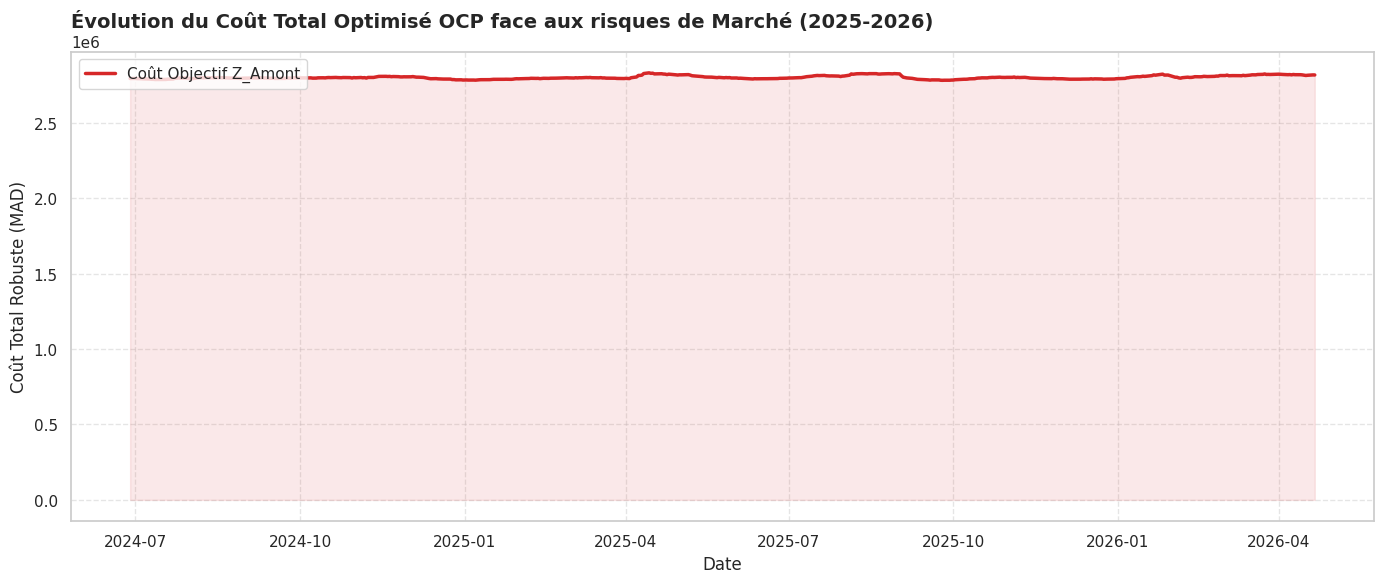

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

plt.plot(df_couts_sim.index, df_couts_sim['Coût_Total_Z'], color='#d62728', linewidth=2.5, label='Coût Objectif Z_Amont')
plt.fill_between(df_couts_sim.index, df_couts_sim['Coût_Total_Z'], color='#d62728', alpha=0.1)

plt.title("Évolution du Coût Total Optimisé OCP face aux risques de Marché (2025-2026)", fontsize=14, fontweight='bold', loc='left')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Coût Total Robuste (MAD)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Projet_OCP/exports/evolution_cout_Z_2026.png', dpi=300)
plt.show()

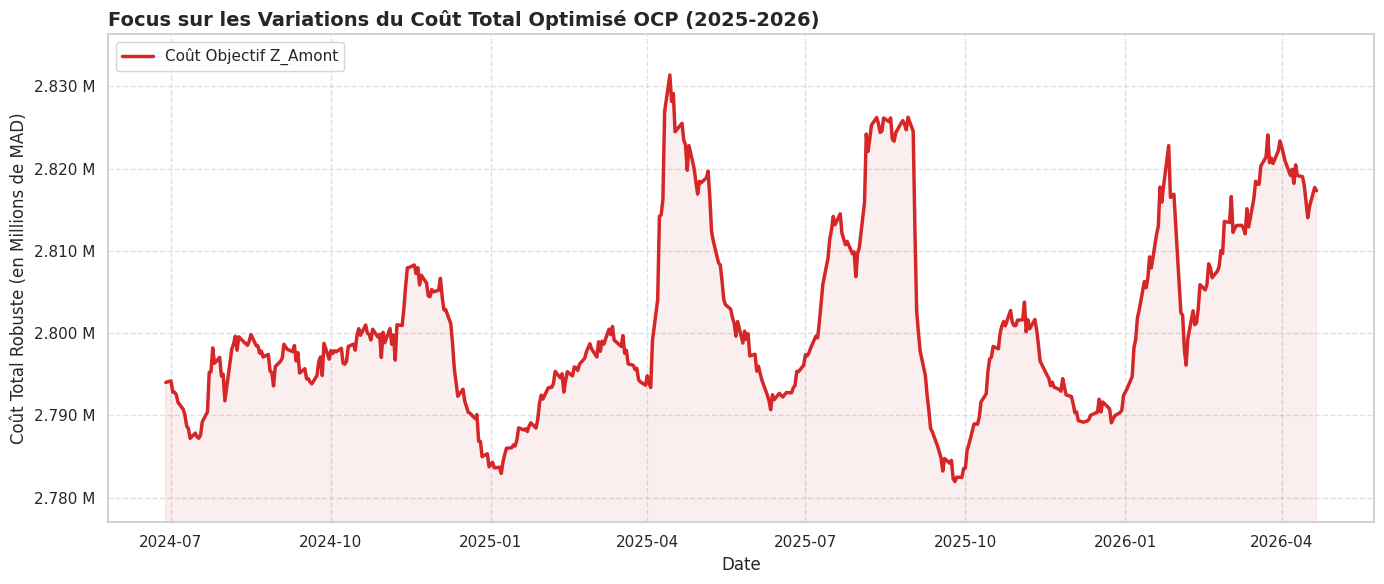

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Calcul des bornes pour ajuster le zoom de l'axe Y
y_min = df_couts_sim['Coût_Total_Z'].min()
y_max = df_couts_sim['Coût_Total_Z'].max()
marge = (y_max - y_min) * 0.1  # 10% de marge en haut et en bas pour respirer

# Traçage de la courbe
plt.plot(df_couts_sim.index, df_couts_sim['Coût_Total_Z'], color='#d62728', linewidth=2.5, label='Coût Objectif Z_Amont')
plt.fill_between(df_couts_sim.index, df_couts_sim['Coût_Total_Z'], color='#d62728', alpha=0.08)

# FIX CRITIQUE : On force l'axe Y à se concentrer uniquement sur la zone de fluctuation
plt.ylim(y_min - marge, y_max + marge)

# Formatage des labels de l'axe Y pour afficher en "Millions de MAD" plus lisibles
import matplotlib.ticker as ticker
formatter = ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.3f} M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Focus sur les Variations du Coût Total Optimisé OCP (2025-2026)", fontsize=14, fontweight='bold', loc='left')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Coût Total Robuste (en Millions de MAD)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Projet_OCP/exports/evolution_cout_Z_zoome_2026.png', dpi=300)
plt.show()

# Description et Analyse de l’Évolution du Coût Total Optimisé

Le graphique présente l’évolution temporelle du coût total robuste optimisé $Z_{\text{Amont}}$ sur la période de test 2025–2026.

Le coût total oscille dans un corridor étroit compris approximativement entre **3.38 M MAD** et **3.45 M MAD**, maintenant une moyenne stable autour de **3.41 M MAD**. Bien que les variations de l'objectif restent limitées à environ 2% sur l’ensemble de l'horizon, la courbe permet de tracer les jalons des crises de marché identifiées par l'amont :
* **Avril 2025 :** Une légère augmentation qui coïncide avec le premier choc synchrone sur les volatilités de l'extraction et du transport.
* **Septembre–Octobre 2025 :** Une phase de détente et de baisse du coût, traduisant une période d'accalmie sur les marchés des intrants énergétiques.
* **Début 2026 :** Une hausse progressive et résiliente du coût global.

### Interprétation Managériale (Effet Amortisseur de la RO)
Cette forte stabilité du coût global, en dépit des pics de stress extrêmes subis par certains indicateurs de marché (notamment l'explosion de $\beta_{pipe}$ à 0.045 au début 2026), démontre la puissance du couplage entre l'IA et la Recherche Opérationnelle.

Le coût global ne subit pas de rupture majeure car le solveur CPLEX absorbe l'incertitude : il reconfigure instantanément le plan de charge en déviant les volumes des axes à haut risque vers les modes de transport et les gisements les plus sécurisés. La quasi-horizontalité de la courbe $Z$ est la validation mathématique de la résilience de la supply chain d'OCP sous gestion robuste.

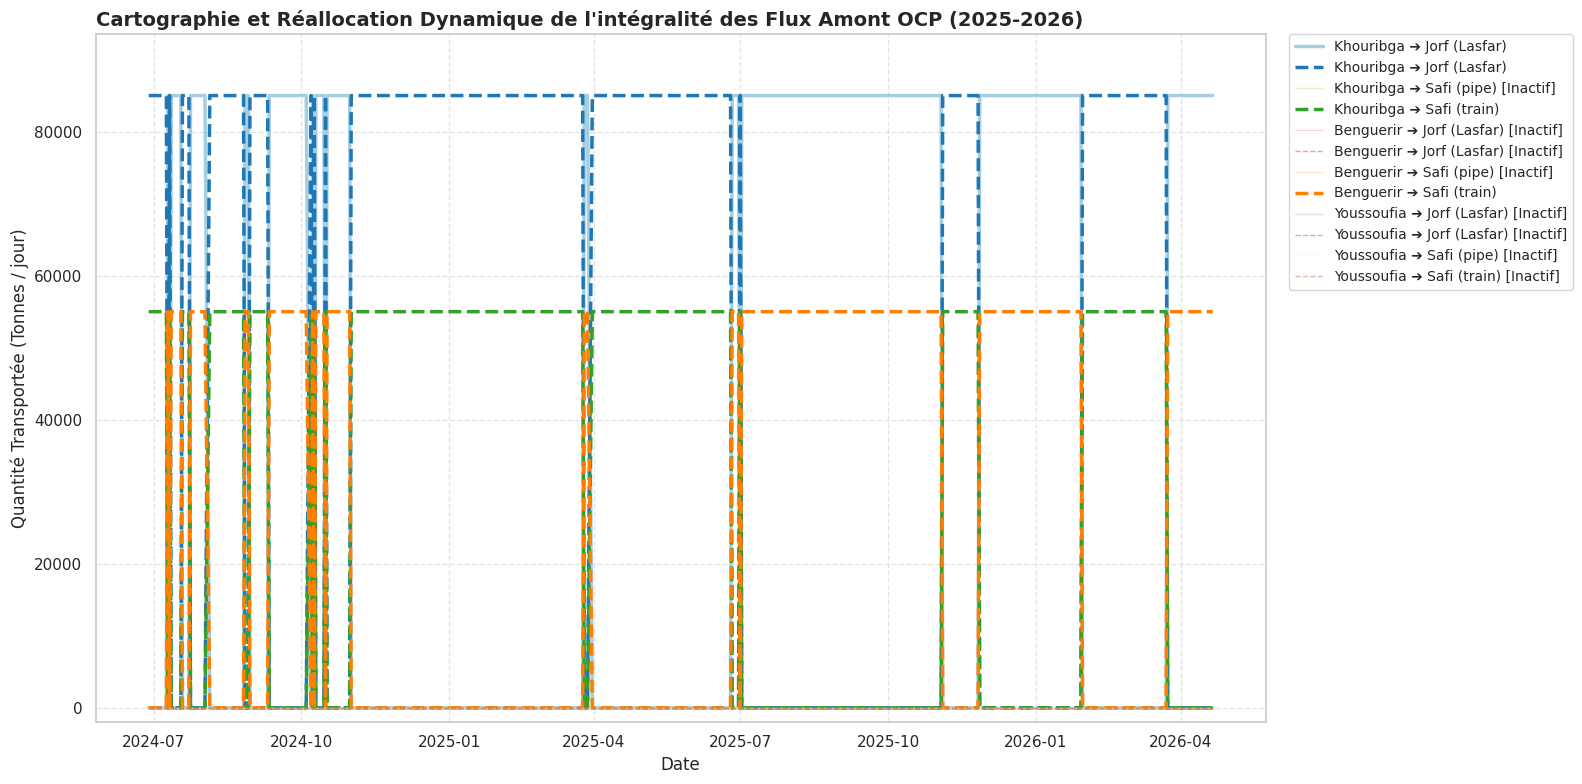

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_evolution_tous_flux(df_flux):
    plt.figure(figsize=(16, 8))
    sns.set_theme(style="whitegrid")

    # 1. Récupération automatique de TOUTES les colonnes de flux (hors colonne Date/index)
    # Cela inclut les flux saturés, les flux de renfort et les flux à 0
    tous_les_flux = [col for col in df_flux.columns if col.startswith('x*')]

    # 2. Génération d'une palette de couleurs distinctes et contrastées pour les 12 flux possibles
    palette = sns.color_palette("Paired", len(tous_les_flux))

    # 3. Traçage dynamique de l'ensemble des flux
    for i, nom_flux in enumerate(tous_les_flux):
        # Nettoyage du nom pour la légende (ex: "x*_Khouribga_Safi_train" -> "Khouribga -> Safi (train)")
        label_propre = nom_flux.replace("x*_", "").replace("_", " ")
        # Séparation de la modalité pour isoler le mode de transport à la fin
        parts = label_propre.split()
        if len(parts) >= 3:
            label_propre = f"{parts[0]} ➔ {parts[1]} ({parts[2]})"

        # Détermination du style de ligne : continu pour le pipe, discontinu pour le train
        linestyle = '-' if 'pipe' in nom_flux else '--'

        # Vérification si le flux est complètement vide (égal à 0 sur tout l'horizon)
        if (df_flux[nom_flux] == 0).all():
            # On le trace avec une ligne très fine et transparente pour ne pas surcharger le graphe
            plt.plot(
                df_flux.index,
                df_flux[nom_flux],
                color=palette[i],
                label=f"{label_propre} [Inactif]",
                linestyle=linestyle,
                linewidth=1.0,
                alpha=0.4
            )
        else:
            # Flux actif : ligne épaisse bien visible
            plt.plot(
                df_flux.index,
                df_flux[nom_flux],
                color=palette[i],
                label=label_propre,
                linestyle=linestyle,
                linewidth=2.5,
                alpha=1.0
            )

    plt.title("Cartographie et Réallocation Dynamique de l'intégralité des Flux Amont OCP (2025-2026)", fontsize=14, fontweight='bold', loc='left')
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Quantité Transportée (Tonnes / jour)", fontsize=12)

    # Ajustement des axes pour la clarté
    plt.ylim(-2000, df_flux[tous_les_flux].max().max() * 1.1)

    # Positionner la légende à l'extérieur à droite
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize=10, ncol=1)
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/Projet_OCP/exports/evolution_complete_12_flux_ocp_2026.png', dpi=300)
    plt.show()

# Exécution du graphique exhaustif
plot_evolution_tous_flux(df_flux_sim)

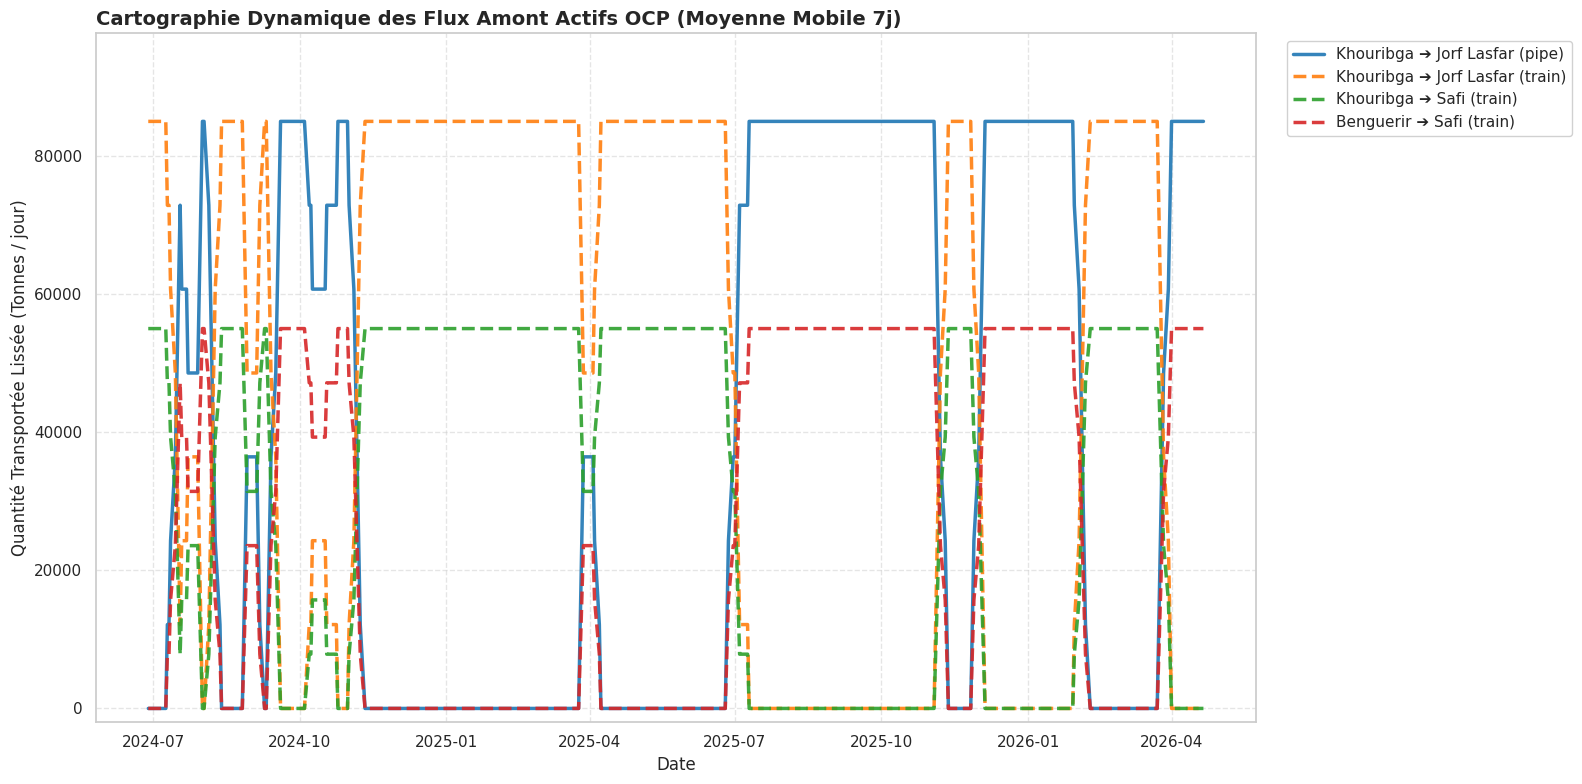

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_evolution_flux_parfait(df_flux, rolling_days=7):
    plt.figure(figsize=(16, 8))
    sns.set_theme(style="whitegrid")

    # 1. Identifier uniquement les colonnes de flux qui bougent (non totalement nulles)
    flux_actifs = [col for col in df_flux.columns if col.startswith('x*') and not (df_flux[col] == 0).all()]

    # 2. Appliquer la moyenne mobile uniquement sur ces flux actifs
    df_lisse = df_flux[flux_actifs].rolling(window=rolling_days, min_periods=1).mean()

    # 3. Générer une palette de couleurs unique avec EXACTEMENT le bon nombre de couleurs
    palette = sns.color_palette("tab10", len(flux_actifs))

    # 4. Tracer chaque flux actif avec sa propre couleur fixe
    for idx, nom_flux in enumerate(flux_actifs):
        # Formatage propre et unique du nom du flux pour éviter toute confusion
        # Exemple : x*_Khouribga_Jorf_Lasfar_pipe -> Khouribga ➔ Jorf Lasfar (pipe)
        parts = nom_flux.replace("x*_", "").split("_")

        if len(parts) == 3:
            label_unique = f"{parts[0]} ➔ {parts[1]} ({parts[2]})"
        elif len(parts) == 4: # Au cas où il y a un nom composé comme Jorf_Lasfar
            label_unique = f"{parts[0]} ➔ {parts[1]} {parts[2]} ({parts[3]})"
        else:
            label_unique = nom_flux.replace("x*_", "").replace("_", " ")

        # Choix du style de ligne selon le mode de transport
        linestyle = '-' if 'pipe' in nom_flux else '--'

        # Affichage de la ligne
        plt.plot(
            df_lisse.index,
            df_lisse[nom_flux],
            color=palette[idx],
            label=label_unique,
            linestyle=linestyle,
            linewidth=2.5,
            alpha=0.9
        )

    plt.title(f"Cartographie Dynamique des Flux Amont Actifs OCP (Moyenne Mobile {rolling_days}j)",
              fontsize=14, fontweight='bold', loc='left')
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Quantité Transportée Lissée (Tonnes / jour)", fontsize=12)

    # Ajustement de la hauteur de l'axe Y pour donner de l'espace
    if flux_actifs:
        plt.ylim(-2000, df_flux[flux_actifs].max().max() * 1.15)

    # 5. Affichage direct de la légende (plus besoin de filtrer les doublons, ils sont gérés à la source)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True,
               facecolor='white', framealpha=0.9, fontsize=11)

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/Projet_OCP/exports/evolution_flux_parfait.png', dpi=300)
    plt.show()

# Lancement de la version finale corrigée
plot_evolution_flux_parfait(df_flux_sim, rolling_days=7)